# Deng control-volume reconstruction for the nonconforming opposite-diagonal MMS (P0 multiplier)

This notebook solves the same full-diagonal Deng MMS fracture problem as `LCG_Deng_flux_reconstruction_MMS_conforming_P0.ipynb`, but the unit-square bulk mesh is triangularized with the opposite local diagonal in each square. The physical fracture remains `(0, 0) -> (1, 1)`, so it cuts through triangle interiors and is coupled with an independent 1D fracture mesh and P0 multiplier mesh.

The `.msh` bulk mesh is generated only if the requested refinement file is missing. Existing `regular_tri_opposite_diagonal_*.msh` files are reused unchanged.


In [49]:
# ============================================================
# Configuration and imports
# ============================================================
from mpi4py import MPI
import numpy as np
import math
import time
import pathlib
import importlib.util
import basix
import matplotlib.pyplot as plt
from tqdm import tqdm

from dolfinx import mesh, fem, geometry
from dolfinx.fem import petsc
from petsc4py import PETSc
try:
    from dolfinx.io import gmsh as gmshio
except ImportError:
    from dolfinx.io import gmshio
import ufl

# Matrix/fracture pressure order.  The multiplier is DG0/P0 by default.
order = 1
lambda_order = 0
Gamma_tag = 2  # kept for compatibility; the opposite-diagonal mesh has no Gamma facets.

# Independent 1D mesh sizes. The fracture pressure mesh uses h_gamma ~= h/2,
# while the P0 multiplier is coarser to avoid the nonconforming inf-sup trouble.
FRACTURE_PRESSURE_LC_FACTOR = 0.5
LAMBDA_COARSEN = 3.0
MULTIPLIER_LC_FACTOR = LAMBDA_COARSEN

# Meshes are created on demand only when the .msh file is missing.
BULK_MESH_BASENAME = "regular_tri_opposite_diagonal"
CREATE_MISSING_MESHES = True
MESH_GENERATOR_NAME = "generate_regular_tri_opposite_diagonal_meshes.py"

# Section 0: convergence analysis. Keep False for a quick diagnostic run.
RUN_CONVERGENCE = False
CONV_REFS = [2, 3, 4, 5, 6, 7]

CASES = [
    {"name": "order1_P0", "order": 1, "lambda_order": 0},
    {"name": "order2_P0", "order": 2, "lambda_order": 0},
    {"name": "order2_P1", "order": 2, "lambda_order": 1}
]
RESULTS_DIR = pathlib.Path("deng_convergence_results/nonconforming_opposite_diagonal")

# Main comparison run.
REF_DEMO = 6

# Jump/error summaries exclude the tip layer below.
TIP_FRAC = 0.10

# Residual-map color range. Values outside this range are saturated.
RK_LOG_VMIN = -10.0
RK_LOG_VMAX = -1.0
RK_CBAR_TICKS = np.arange(RK_LOG_VMIN, RK_LOG_VMAX + 1, 1, dtype=float)

Lx, Ly = 1.0, 1.0
x_start, x_end = 0.0, 1.0
y_start, y_end = 0.0, 1.0
FRAC_A = np.array([x_start, y_start], dtype=float)
FRAC_B = np.array([x_end, y_end], dtype=float)
ALPHA = 1.0
K_M_VALUE = 1.0
K_F_VALUE = 100.0

comm = MPI.COMM_SELF
rank = comm.rank

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})


In [50]:
# ============================================================
# MMS data and idempotent opposite-diagonal mesh lookup
# ============================================================
def unit(v):
    v = np.asarray(v, dtype=float)
    nrm = np.linalg.norm(v)
    if nrm == 0.0:
        raise ValueError("zero-length vector")
    return v / nrm


tau_np = unit(FRAC_B - FRAC_A)
normal_np = np.array([-tau_np[1], tau_np[0]], dtype=float)
L_gamma = float(np.linalg.norm(FRAC_B - FRAC_A))


def _fracture_problem_dirs():
    here = pathlib.Path.cwd()
    return [
        here,
        here / "fenicsx/code/fracture problem",
        pathlib.Path("fenicsx/code/fracture problem"),
        pathlib.Path(__file__).resolve().parent if "__file__" in globals() else here,
    ]


def _find_fracture_problem_file(name):
    tried = []
    for root in _fracture_problem_dirs():
        p = root / name
        tried.append(str(p))
        if p.exists():
            return p.resolve()
    return None


def mesh_path_for_ref(ref):
    name = f"{BULK_MESH_BASENAME}_{int(ref)}.msh"
    found = _find_fracture_problem_file(name)
    if found is not None:
        return str(found)
    if not CREATE_MISSING_MESHES:
        raise FileNotFoundError(f"Could not find {name} and CREATE_MISSING_MESHES=False")

    script = _find_fracture_problem_file(MESH_GENERATOR_NAME)
    if script is None:
        raise FileNotFoundError(f"Could not find {MESH_GENERATOR_NAME}; cannot create {name}")
    spec = importlib.util.spec_from_file_location("regular_tri_opposite_meshgen", script)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    target = mod.generate_mesh(int(ref), script.parent, overwrite=False)
    return str(pathlib.Path(target).resolve())


def real_points_np(s):
    s = np.asarray(s, dtype=float).reshape(-1)
    return FRAC_A[None, :] + s[:, None] * tau_np[None, :]


def signed_distance_np(points):
    return (np.asarray(points, dtype=float)[:, :2] - FRAC_A[None, :]) @ normal_np


def s_coord_np(points):
    return (np.asarray(points, dtype=float)[:, :2] - FRAC_A[None, :]) @ tau_np


def q_exact_xy(x0, y0):
    return np.sin(np.pi * x0) * np.sin(np.pi * y0)


def r_exact_xy(x0, y0):
    return normal_np[0] * (x0 - FRAC_A[0]) + normal_np[1] * (y0 - FRAC_A[1])


def p_m_exact_xy(x0, y0):
    q = q_exact_xy(x0, y0)
    return q + ALPHA * np.abs(r_exact_xy(x0, y0)) * q


def p_gamma_exact_xy(x0, y0):
    return q_exact_xy(x0, y0)


def lambda_exact_xy(x0, y0):
    return -2.0 * ALPHA * q_exact_xy(x0, y0)


def p_m_exact_fn(x):
    return p_m_exact_xy(x[0], x[1])


def p_f_exact_fn(t):
    return np.sin(np.pi * t) ** 2


def lam_exact_fn(t):
    return -2.0 * ALPHA * np.sin(np.pi * t) ** 2


def grad_q_exact_xy(x0, y0):
    return np.column_stack([
        np.pi * np.cos(np.pi * x0) * np.sin(np.pi * y0),
        np.pi * np.sin(np.pi * x0) * np.cos(np.pi * y0),
    ])


def exact_grad_p(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    x = pts[:, 0]
    y = pts[:, 1]
    q = q_exact_xy(x, y)
    grad_q = grad_q_exact_xy(x, y)
    r = r_exact_xy(x, y)
    sign_r = np.where(r >= 0.0, 1.0, -1.0)
    return grad_q + ALPHA * (
        sign_r[:, None] * normal_np[None, :] * q[:, None]
        + np.abs(r)[:, None] * grad_q
    )


def exact_q(points):
    return -K_M_VALUE * exact_grad_p(points)


def exact_dp_gamma_ds(s):
    pts = real_points_np(s)
    grad_q = grad_q_exact_xy(pts[:, 0], pts[:, 1])
    return grad_q @ tau_np


def f_m_exact_xy(x0, y0):
    q = q_exact_xy(x0, y0)
    r = r_exact_xy(x0, y0)
    sign_r = np.where(r >= 0.0, 1.0, -1.0)
    n_dot_grad_q = (
        normal_np[0] * np.pi * np.cos(np.pi * x0) * np.sin(np.pi * y0)
        + normal_np[1] * np.pi * np.sin(np.pi * x0) * np.cos(np.pi * y0)
    )
    return K_M_VALUE * (
        2.0 * np.pi**2 * q
        + 2.0 * ALPHA * np.pi**2 * np.abs(r) * q
        - 2.0 * ALPHA * sign_r * n_dot_grad_q
    )


def f_m_exact_points(points):
    points = np.asarray(points, dtype=float)
    return f_m_exact_xy(points[:, 0], points[:, 1])


def f_callable(x):
    return f_m_exact_xy(x[0], x[1])


def f_gamma_exact_xy(x0, y0):
    qg = q_exact_xy(x0, y0)
    d2_q_ds2 = (
        -np.pi**2 * qg
        + 2.0 * np.pi**2 * tau_np[0] * tau_np[1]
        * np.cos(np.pi * x0) * np.cos(np.pi * y0)
    )
    return -K_F_VALUE * d2_q_ds2 + lambda_exact_xy(x0, y0)


def ff_callable(x):
    return f_gamma_exact_xy(x[0], x[1])


def k_callable(x):
    return (x[0] * 0.0 + K_M_VALUE)[np.newaxis, :]


In [51]:
# ============================================================
# Nonconforming LCG solve on opposite-diagonal triangular bulk meshes
# ============================================================
def gauss_interval(n):
    x, w = np.polynomial.legendre.leggauss(int(n))
    return 0.5 * (x + 1.0), 0.5 * w


_GL, _WL = gauss_interval(12)


def _space_ndofs(V):
    return int(V.dofmap.index_map.size_local * V.dofmap.index_map_bs)


def estimate_bulk_h(omega):
    coords = omega.geometry.x[:, :2]

    def min_positive_spacing(values):
        vals = np.unique(np.round(np.sort(values), 14))
        diffs = np.diff(vals)
        diffs = diffs[diffs > 1.0e-12]
        return float(diffs.min()) if diffs.size else np.inf

    return min(min_positive_spacing(coords[:, 0]), min_positive_spacing(coords[:, 1]))


def make_line_mesh_from_s_nodes(s_nodes):
    s_nodes = np.asarray(s_nodes, dtype=float)
    nodes = real_points_np(s_nodes)
    n_cells = len(s_nodes) - 1
    cells = np.column_stack([np.arange(n_cells), np.arange(1, n_cells + 1)]).astype(np.int64)
    coord_el = ufl.Mesh(basix.ufl.element("Lagrange", basix.CellType.interval, 1, shape=(2,)))
    try:
        gamma_mesh = mesh.create_mesh(comm, cells, coord_el, nodes)
    except (TypeError, AttributeError, IndexError):
        gamma_mesh = mesh.create_mesh(comm, cells, nodes, coord_el)
    return gamma_mesh, float(np.max(np.diff(s_nodes))), int(n_cells), s_nodes


def make_fracture_meshes(h):
    h_gamma_target = FRACTURE_PRESSURE_LC_FACTOR * h
    h_lambda_target = MULTIPLIER_LC_FACTOR * h
    n_gamma = max(1, int(np.ceil(L_gamma / h_gamma_target)))
    n_lambda = max(1, int(np.ceil(L_gamma / h_lambda_target)))
    s_gamma = np.linspace(0.0, L_gamma, n_gamma + 1)
    s_lambda = np.linspace(0.0, L_gamma, n_lambda + 1)
    gamma, h_gamma, n_gamma, _ = make_line_mesh_from_s_nodes(s_gamma)
    gamma_l, h_lambda, n_lambda, _ = make_line_mesh_from_s_nodes(s_lambda)
    return gamma, gamma_l, h_gamma, h_lambda, n_gamma, n_lambda, s_gamma, s_lambda


def build_bulk_trace_data(omega, V_m):
    tdim = omega.topology.dim
    fdim = tdim - 1
    for pair in [(tdim, 0), (fdim, 0), (tdim, fdim)]:
        omega.topology.create_connectivity(*pair)
    c2v = omega.topology.connectivity(tdim, 0)
    geom = omega.geometry.x[:, :2]
    elem = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, order)
    dofmap = V_m.dofmap
    cells = []
    for ci in range(omega.topology.index_map(tdim).size_local):
        verts = np.asarray(c2v.links(ci), dtype=np.int32)
        coords = geom[verts]
        J = np.column_stack((coords[1] - coords[0], coords[2] - coords[0]))
        cells.append({
            "cell_id": int(ci),
            "verts": verts,
            "coords": coords,
            "J": J,
            "invJ": np.linalg.inv(J),
            "dofs": np.asarray(dofmap.cell_dofs(ci), dtype=np.int32),
            "elem": elem,
        })
    tree = geometry.bb_tree(omega, tdim)
    return {"omega": omega, "cells": cells, "tree": tree, "elem": elem}


def locate_bulk_cell_xy(pt, bulk_trace, tol=1.0e-12):
    omega = bulk_trace["omega"]
    pts3 = np.zeros((1, 3), dtype=float)
    pts3[0, :2] = np.asarray(pt, dtype=float)[:2]
    candidates = geometry.compute_collisions_points(bulk_trace["tree"], pts3)
    colliding = geometry.compute_colliding_cells(omega, candidates, pts3)
    links = colliding.links(0)
    if len(links):
        return bulk_trace["cells"][int(links[0])]
    for shift in [tol * normal_np, -tol * normal_np, tol * tau_np, -tol * tau_np]:
        pts3[0, :2] = np.asarray(pt, dtype=float)[:2] + shift
        candidates = geometry.compute_collisions_points(bulk_trace["tree"], pts3)
        colliding = geometry.compute_colliding_cells(omega, candidates, pts3)
        links = colliding.links(0)
        if len(links):
            return bulk_trace["cells"][int(links[0])]
    raise RuntimeError(f"Could not locate bulk triangle containing point {pt}")


def triangle_values_grads_on_cell(cell, points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    xi = (pts - cell["coords"][0]) @ cell["invJ"].T
    tab = _tab(cell["elem"], 1, xi)
    vals = tab[0]
    ref_grads = np.stack([tab[1], tab[2]], axis=2)
    grads = ref_grads @ cell["invJ"]
    return vals, grads


def fracture_breakpoints_from_bulk_mesh(omega, tol=1.0e-12):
    tdim = omega.topology.dim
    fdim = tdim - 1
    omega.topology.create_connectivity(fdim, 0)
    f2v = omega.topology.connectivity(fdim, 0)
    geom = omega.geometry.x[:, :2]
    s_vals = [0.0, L_gamma]
    for fi in range(omega.topology.index_map(fdim).size_local):
        verts = np.asarray(f2v.links(fi), dtype=np.int32)
        if len(verts) != 2:
            continue
        s_int = segment_edge_s_intersection(geom[int(verts[0])], geom[int(verts[1])], tol=tol)
        if s_int is not None:
            s_vals.append(float(s_int))
    s_vals = np.array(sorted(s_vals), dtype=float)
    unique = []
    for s in s_vals:
        if not unique or abs(s - unique[-1]) > 1.0e-11:
            unique.append(float(np.clip(s, 0.0, L_gamma)))
    return np.asarray(unique, dtype=float)


def s_breakpoints(s0, s1, s_nodes, tol=1.0e-12):
    s0 = float(s0); s1 = float(s1)
    if s1 < s0:
        s0, s1 = s1, s0
    inside = np.asarray(s_nodes, dtype=float)
    inside = inside[(inside > s0 + tol) & (inside < s1 - tol)]
    return np.concatenate(([s0], np.unique(np.round(inside, 14)), [s1])).astype(float)


def lagrange_1d_values_and_derivatives(nodes, x):
    nodes = np.asarray(nodes, dtype=float).reshape(-1)
    x = np.asarray(x, dtype=float).reshape(-1)
    n = len(nodes)
    vals = np.ones((x.size, n), dtype=float)
    ders = np.zeros((x.size, n), dtype=float)
    if n == 1:
        return vals, ders
    for i in range(n):
        for j in range(n):
            if j != i:
                vals[:, i] *= (x - nodes[j]) / (nodes[i] - nodes[j])
        for k in range(n):
            if k == i:
                continue
            term = np.ones_like(x) / (nodes[i] - nodes[k])
            for j in range(n):
                if j != i and j != k:
                    term *= (x - nodes[j]) / (nodes[i] - nodes[j])
            ders[:, i] += term
    return vals, ders


def build_line_space_data(domain, V):
    domain.topology.create_connectivity(domain.topology.dim, 0)
    c2v = domain.topology.connectivity(domain.topology.dim, 0)
    geom_s = s_coord_np(domain.geometry.x[:, :2])
    dof_coords = V.tabulate_dof_coordinates()[:, :2]
    dof_s_all = s_coord_np(dof_coords)
    cells = []
    s_nodes = []
    for ci in range(domain.topology.index_map(domain.topology.dim).size_local):
        verts = np.asarray(c2v.links(ci), dtype=np.int32)
        s0, s1 = np.sort(geom_s[verts])
        dofs = np.asarray(V.dofmap.cell_dofs(ci), dtype=np.int32)
        dof_s = dof_s_all[dofs]
        ell = float(s1 - s0)
        if ell <= 0.0:
            continue
        nodes = np.unique(np.round((dof_s - s0) / ell, 14))
        dof_node_idx = np.searchsorted(nodes, np.round((dof_s - s0) / ell, 14))
        cells.append({
            "cell_id": int(ci),
            "dofs": dofs,
            "s0": float(s0),
            "s1": float(s1),
            "ell": ell,
            "nodes": nodes,
            "dof_node_idx": dof_node_idx,
        })
        s_nodes.extend([float(s0), float(s1)])
    s_nodes = np.array(sorted(set(np.round(s_nodes, 14))), dtype=float)
    cells = [cells[i] for i in np.argsort([c["s0"] for c in cells])]
    return {"cells": cells, "s_nodes": s_nodes}


def locate_line_cell_s(s, line_data, tol=1.0e-12):
    cells = line_data["cells"]
    if s <= cells[0]["s0"] + tol:
        return cells[0]
    if s >= cells[-1]["s1"] - tol:
        return cells[-1]
    starts = np.array([c["s0"] for c in cells], dtype=float)
    idx = int(np.searchsorted(starts, s, side="right") - 1)
    return cells[min(max(idx, 0), len(cells) - 1)]


def line_values_derivatives_on_cell(cell, s):
    s = np.asarray(s, dtype=float).reshape(-1)
    xi = (s - cell["s0"]) / cell["ell"]
    L, dL = lagrange_1d_values_and_derivatives(cell["nodes"], xi)
    nd = len(cell["dofs"])
    vals = np.zeros((s.size, nd), dtype=float)
    ders = np.zeros((s.size, nd), dtype=float)
    for a in range(nd):
        ia = cell["dof_node_idx"][a]
        vals[:, a] = L[:, ia]
        ders[:, a] = dL[:, ia] / cell["ell"]
    return vals, ders


def assemble_fracture_and_trace_blocks(A, b, gamma, gamma_l, V_f, V_l, bulk_trace, offsets, bulk_s_nodes):
    off_m, off_f, off_l = offsets
    pressure_data = build_line_space_data(gamma, V_f)
    multiplier_data = build_line_space_data(gamma_l, V_l)

    # Fracture pressure equation: int K_f dp_f/ds dpsi/ds + int lambda psi = int f_f psi.
    for cell in pressure_data["cells"]:
        fdofs = cell["dofs"].astype(np.int32)
        s_q = cell["s0"] + cell["ell"] * _GL
        x_q = real_points_np(s_q)
        psi, dpsi = line_values_derivatives_on_cell(cell, s_q)
        weight = cell["ell"] * _WL
        Kloc = K_F_VALUE * np.einsum("q,qi,qj->ij", weight, dpsi, dpsi)
        floc = np.einsum("q,q,qi->i", weight, f_gamma_exact_xy(x_q[:, 0], x_q[:, 1]), psi)
        A.setValues(off_f + fdofs, off_f + fdofs, Kloc, addv=PETSc.InsertMode.ADD_VALUES)
        b.setValues(off_f + fdofs, floc, addv=PETSc.InsertMode.ADD_VALUES)

    for lcell in multiplier_data["cells"]:
        ldofs = lcell["dofs"].astype(np.int32)
        s0, s1 = lcell["s0"], lcell["s1"]

        pbreaks = s_breakpoints(s0, s1, pressure_data["s_nodes"])
        for a, c in zip(pbreaks[:-1], pbreaks[1:]):
            if c - a <= 1.0e-14:
                continue
            pcell = locate_line_cell_s(0.5 * (a + c), pressure_data)
            fdofs = pcell["dofs"].astype(np.int32)
            s_q = a + (c - a) * _GL
            psi = line_values_derivatives_on_cell(pcell, s_q)[0]
            mu = line_values_derivatives_on_cell(lcell, s_q)[0]
            weight = (c - a) * _WL
            A.setValues(off_f + fdofs, off_l + ldofs, np.einsum("q,qi,qj->ij", weight, psi, mu), addv=PETSc.InsertMode.ADD_VALUES)
            A.setValues(off_l + ldofs, off_f + fdofs, -np.einsum("q,qi,qj->ij", weight, mu, psi), addv=PETSc.InsertMode.ADD_VALUES)

        bbreaks = s_breakpoints(s0, s1, bulk_s_nodes)
        for a, c in zip(bbreaks[:-1], bbreaks[1:]):
            if c - a <= 1.0e-14:
                continue
            s_mid = 0.5 * (a + c)
            bulk_cell = locate_bulk_cell_xy(real_points_np([s_mid])[0], bulk_trace)
            mdofs = bulk_cell["dofs"].astype(np.int32)
            s_q = a + (c - a) * _GL
            x_q = real_points_np(s_q)
            phi = triangle_values_grads_on_cell(bulk_cell, x_q)[0]
            mu = line_values_derivatives_on_cell(lcell, s_q)[0]
            weight = (c - a) * _WL
            A.setValues(mdofs, off_l + ldofs, -np.einsum("q,qi,qj->ij", weight, phi, mu), addv=PETSc.InsertMode.ADD_VALUES)
            A.setValues(off_l + ldofs, mdofs, np.einsum("q,qi,qj->ij", weight, mu, phi), addv=PETSc.InsertMode.ADD_VALUES)


def apply_pressure_bcs(A, b, V_m, V_f, offsets):
    off_m, off_f, _ = offsets
    coords_m = V_m.tabulate_dof_coordinates()[:, :2]
    coords_f = V_f.tabulate_dof_coordinates()[:, :2]
    tol = 1.0e-10
    bnd_m = np.where(
        np.isclose(coords_m[:, 0], 0.0, atol=tol)
        | np.isclose(coords_m[:, 0], Lx, atol=tol)
        | np.isclose(coords_m[:, 1], 0.0, atol=tol)
        | np.isclose(coords_m[:, 1], Ly, atol=tol)
    )[0].astype(np.int32)
    tip_a = np.where(np.linalg.norm(coords_f - FRAC_A[None, :], axis=1) < 100 * tol)[0].astype(np.int32)
    tip_b = np.where(np.linalg.norm(coords_f - FRAC_B[None, :], axis=1) < 100 * tol)[0].astype(np.int32)
    if len(tip_a) != 1 or len(tip_b) != 1:
        raise RuntimeError(f"Could not identify fracture-tip dofs: A={tip_a}, B={tip_b}")
    bc_idx = np.concatenate([off_m + bnd_m, off_f + tip_a, off_f + tip_b]).astype(np.int32)
    bc_vals = np.concatenate([
        p_m_exact_xy(coords_m[bnd_m, 0], coords_m[bnd_m, 1]),
        p_gamma_exact_xy(coords_f[tip_a, 0], coords_f[tip_a, 1]),
        p_gamma_exact_xy(coords_f[tip_b, 0], coords_f[tip_b, 1]),
    ]).astype(float)
    x_bc = A.createVecRight()
    x_bc.set(0.0)
    x_bc.setValues(bc_idx, bc_vals)
    x_bc.assemble()
    A.zeroRowsColumns(bc_idx, diag=1.0, x=x_bc, b=b)
    return bc_idx, bc_vals


def solve_petsc_lu(A, b, prefix):
    x = A.createVecRight()
    x.set(0.0)
    last_error = None
    for factor_solver in ("mumps", None):
        try:
            ksp = PETSc.KSP().create(PETSc.COMM_SELF)
            ksp.setOptionsPrefix(prefix)
            ksp.setOperators(A)
            ksp.setType(PETSc.KSP.Type.PREONLY)
            pc = ksp.getPC()
            pc.setType(PETSc.PC.Type.LU)
            if factor_solver is not None:
                pc.setFactorSolverType(factor_solver)
            ksp.setFromOptions()
            ksp.solve(b, x)
            reason = ksp.getConvergedReason()
            if reason < 0:
                raise RuntimeError(f"PETSc KSP failed with reason {reason}")
            return x, factor_solver or "petsc-lu"
        except Exception as exc:
            last_error = exc
            if factor_solver is None:
                raise
    raise RuntimeError("LU solve failed") from last_error


def solve_lcg_mms(ref, verbose=False):
    filename = mesh_path_for_ref(ref)
    omega, cell_markers, facet_markers = gmshio.read_from_msh(
        filename, comm, 0, gdim=2
    )[0:3]
    h = estimate_bulk_h(omega)
    gamma, gamma_l, h_gamma, h_lambda, n_gamma, n_lambda, s_gamma, s_lambda = make_fracture_meshes(h)

    V_m = fem.functionspace(omega, ("Lagrange", order))
    V_f = fem.functionspace(gamma, ("Lagrange", order))
    V_l = fem.functionspace(gamma_l, ("DG", 0)) if lambda_order == 0 else fem.functionspace(gamma_l, ("Lagrange", lambda_order))

    n_m = _space_ndofs(V_m)
    n_f = _space_ndofs(V_f)
    n_l = _space_ndofs(V_l)
    off_m, off_f, off_l = 0, n_m, n_m + n_f
    n_total = n_m + n_f + n_l

    f_m = fem.Function(V_m, name="f_m")
    f_m.interpolate(f_callable)
    k_m = fem.Function(V_m, name="k_m")
    k_m.interpolate(k_callable)

    # Keep dx for the pressure-error diagnostic below.  The bulk matrix/load are
    # assembled manually after the monolithic PETSc matrix is created so the LCG
    # solve uses the same Basix quadrature as the Deng local-balance diagnostic.
    dx = ufl.Measure("dx", domain=omega)

    A = PETSc.Mat().createAIJ((n_total, n_total), nnz=120, comm=PETSc.COMM_SELF)
    A.setOption(PETSc.Mat.Option.NEW_NONZERO_ALLOCATION_ERR, False)
    A.setUp()
    b = PETSc.Vec().createSeq(n_total, comm=PETSc.COMM_SELF)
    b.set(0.0)

    # Manual triangular bulk assembly.  Using the same quadrature family as the
    # Deng post-processing avoids a small UFL-vs-diagnostic quadrature mismatch
    # that otherwise leaves fracture-cut R_xi around 1e-7 on refined meshes.
    bulk_degree = max(5, 2 * order + 3)
    X_bulk, w_bulk = basix.make_quadrature(basix.CellType.triangle, bulk_degree)
    elem_bulk = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, order)
    tab_bulk = _tab(elem_bulk, 1, X_bulk)
    phi_bulk = tab_bulk[0]
    ref_grads_bulk = np.stack([tab_bulk[1], tab_bulk[2]], axis=2)
    omega.topology.create_connectivity(omega.topology.dim, 0)
    c2v_bulk = omega.topology.connectivity(omega.topology.dim, 0)
    geom_bulk = omega.geometry.x[:, :2]
    for ci in range(omega.topology.index_map(omega.topology.dim).size_local):
        verts = np.asarray(c2v_bulk.links(ci), dtype=np.int32)
        coords = geom_bulk[verts]
        J = np.column_stack((coords[1] - coords[0], coords[2] - coords[0]))
        detJ = abs(np.linalg.det(J))
        invJ = np.linalg.inv(J)
        phys_grads = ref_grads_bulk @ invJ
        X_phys = coords[0] + X_bulk @ J.T
        cdofs = np.asarray(V_m.dofmap.cell_dofs(ci), dtype=np.int32)
        Ke = detJ * K_M_VALUE * np.einsum("q,qid,qjd->ij", w_bulk, phys_grads, phys_grads)
        fe = detJ * np.einsum("q,q,qi->i", w_bulk, f_m_exact_xy(X_phys[:, 0], X_phys[:, 1]), phi_bulk)
        A.setValues(cdofs, cdofs, Ke, addv=PETSc.InsertMode.ADD_VALUES)
        b.setValues(cdofs, fe, addv=PETSc.InsertMode.ADD_VALUES)

    bulk_trace = build_bulk_trace_data(omega, V_m)
    bulk_s_nodes = fracture_breakpoints_from_bulk_mesh(omega)
    assemble_fracture_and_trace_blocks(A, b, gamma, gamma_l, V_f, V_l, bulk_trace, (off_m, off_f, off_l), bulk_s_nodes)
    A.assemble()
    b.assemble()

    bc_idx, bc_vals = apply_pressure_bcs(A, b, V_m, V_f, (off_m, off_f, off_l))
    A.assemble()
    b.assemble()

    x_sol, factor_solver = solve_petsc_lu(A, b, prefix=f"deng_nonconf_ref{ref}_p{order}_l{lambda_order}_")
    sol = x_sol.getArray(readonly=True)

    p_m = fem.Function(V_m, name="p_m")
    p_f = fem.Function(V_f, name="p_gamma")
    lmbd = fem.Function(V_l, name="lambda_h")
    p_m.x.array[:] = sol[off_m:off_f]
    p_f.x.array[:] = sol[off_f:off_l]
    lmbd.x.array[:] = sol[off_l:off_l + n_l]
    p_m.x.scatter_forward()
    p_f.x.scatter_forward()
    lmbd.x.scatter_forward()

    multiplier_data = build_line_space_data(gamma_l, V_l)

    def _lam_l2(sign):
        e = 0.0
        for cell in multiplier_data["cells"]:
            s_q = cell["s0"] + cell["ell"] * _GL
            x_q = real_points_np(s_q)
            mu = line_values_derivatives_on_cell(cell, s_q)[0]
            val = mu @ lmbd.x.array[cell["dofs"]]
            ex = lambda_exact_xy(x_q[:, 0], x_q[:, 1])
            e += float(np.dot(cell["ell"] * _WL, (sign * val - ex) ** 2))
        return math.sqrt(max(e, 0.0))

    err_lam_plus = _lam_l2(1.0)
    err_lam_minus = _lam_l2(-1.0)
    lambda_balance_sign = 1.0 if err_lam_plus <= err_lam_minus else -1.0
    err_lam = min(err_lam_plus, err_lam_minus)

    p_m_ex = fem.Function(V_m)
    p_m_ex.interpolate(p_m_exact_fn)
    err_pm = math.sqrt(float(omega.comm.allreduce(fem.assemble_scalar(fem.form((p_m - p_m_ex) ** 2 * dx)), op=MPI.SUM)))

    # Fracture pressure L2, integrated on the independent line mesh.
    pressure_data = build_line_space_data(gamma, V_f)
    err_pf_sq = 0.0
    for cell in pressure_data["cells"]:
        s_q = cell["s0"] + cell["ell"] * _GL
        x_q = real_points_np(s_q)
        psi = line_values_derivatives_on_cell(cell, s_q)[0]
        val = psi @ p_f.x.array[cell["dofs"]]
        ex = p_gamma_exact_xy(x_q[:, 0], x_q[:, 1])
        err_pf_sq += float(np.dot(cell["ell"] * _WL, (val - ex) ** 2))
    err_pf = math.sqrt(max(err_pf_sq, 0.0))

    h_lambda_arc = float(np.max(np.diff(s_lambda)))
    h_lambda_x = float(np.max(np.diff(real_points_np(s_lambda)[:, 0])))

    if verbose:
        print(f"ref={ref}: mesh={pathlib.Path(filename).name}, factor={factor_solver}")
        print(f"  matrix={n_m}, fracture={n_f}, lambda={n_l}, total={n_total}")
        print(f"  h={h:.3e}, h_gamma={h_gamma:.3e}, h_lambda_arc={h_lambda_arc:.3e}, sign={lambda_balance_sign:+.0f}")

    return {
        "ref": int(ref),
        "h": float(h),
        "omega": omega,
        "gamma": gamma,
        "gamma_l": gamma_l,
        "gamma_to_omega": None,
        "gamma_vertex_to_omega": None,
        "gamma_entities": np.array([], dtype=np.int32),
        "cell_markers": cell_markers,
        "facet_markers": facet_markers,
        "Gamma_tag": Gamma_tag,
        "V": V_m,
        "V_m": V_m,
        "V_f": V_f,
        "V_l": V_l,
        "p_sol": p_m,
        "p_m": p_m,
        "p_f": p_f,
        "lmbd": lmbd,
        "k_m": k_m,
        "f_m": f_m,
        "all_dofs": bc_idx[bc_idx < off_f].astype(np.int32),
        "bc_idx": bc_idx,
        "bc_vals": bc_vals,
        "iterations": 1,
        "factor_solver": factor_solver,
        "dofs": n_m,
        "dofs_lambda": n_l,
        "lambda_space": ("DG0" if lambda_order == 0 else f"P{lambda_order}"),
        "lambda_t_nodes": real_points_np(s_lambda)[:, 0],
        "lambda_s_nodes": s_lambda,
        "h_gamma": float(h_gamma),
        "h_lambda": h_lambda_arc,
        "h_lambda_arc": h_lambda_arc,
        "n_gamma": int(n_gamma),
        "n_lambda": int(n_lambda),
        "dofs_total": n_total,
        "lambda_balance_sign": lambda_balance_sign,
        "err_pm": err_pm,
        "err_pf": err_pf,
        "err_lam": err_lam,
        "mesh_file": filename,
        "bulk_fracture_s_nodes": bulk_s_nodes,
    }


In [52]:
# ============================================================
# Geometry, quadrature, and field-evaluation helpers
# ============================================================
def cell_centroid(coords):
    return np.mean(coords, axis=0)


def edge_length(a, b):
    return float(np.linalg.norm(np.asarray(b, dtype=float) - np.asarray(a, dtype=float)))


def normal_from_C_to_ti(centroid, midpoint, vi):
    centroid = np.asarray(centroid, dtype=float)
    midpoint = np.asarray(midpoint, dtype=float)
    vi = np.asarray(vi, dtype=float)
    t = midpoint - centroid
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    seg_mid = 0.5 * (centroid + midpoint)
    chosen = n1 if np.dot(n1, vi - seg_mid) < 0.0 else n2
    norm = np.linalg.norm(chosen)
    return chosen / norm if norm > 0.0 else chosen


def outward_edge_normal(a, b, centroid):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    centroid = np.asarray(centroid, dtype=float)
    t = b - a
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    mid = 0.5 * (a + b)
    chosen = n1 if np.dot(n1, mid - centroid) > 0.0 else n2
    norm = np.linalg.norm(chosen)
    return chosen / norm if norm > 0.0 else chosen


def polygon_signed_area(poly):
    poly = np.asarray(poly, dtype=float)
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def order_polygon_vertices(pts):
    pts = np.asarray(pts, dtype=float)
    if len(pts) <= 2:
        return pts
    ctr = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - ctr[1], pts[:, 0] - ctr[0])
    poly = pts[np.argsort(ang)]
    if polygon_signed_area(poly) < 0.0:
        poly = poly[::-1]
    return poly


def extend_line_to_bbox(a, tau, bbox, tol=1e-14):
    xmin, xmax, ymin, ymax = bbox
    ts = []
    if abs(tau[0]) > tol:
        for xval in [xmin, xmax]:
            t = (xval - a[0]) / tau[0]
            y = a[1] + t * tau[1]
            if ymin - tol <= y <= ymax + tol:
                ts.append(t)
    if abs(tau[1]) > tol:
        for yval in [ymin, ymax]:
            t = (yval - a[1]) / tau[1]
            x = a[0] + t * tau[0]
            if xmin - tol <= x <= xmax + tol:
                ts.append(t)
    if len(ts) < 2:
        raise RuntimeError("Could not extend fracture line to bounding box.")
    return min(ts), max(ts)


def _tab(elem, nderiv, pts):
    pts = np.asarray(pts, dtype=float)
    if pts.ndim == 1:
        pts = pts.reshape(1, -1)
    t = elem.tabulate(nderiv, pts)
    return t[..., 0] if t.ndim == 4 else t


_T_G = np.array([0.5 - 0.5 * np.sqrt(3.0 / 5.0), 0.5, 0.5 + 0.5 * np.sqrt(3.0 / 5.0)])
_W_G = np.array([5.0 / 18.0, 4.0 / 9.0, 5.0 / 18.0])
_T_GAUSS = np.array([(1.0 - 1.0 / np.sqrt(3.0)) / 2.0, (1.0 + 1.0 / np.sqrt(3.0)) / 2.0])
_W_GAUSS = np.array([0.5, 0.5])


def error_quadrature_degree(degree=None):
    return max(5, 2 * order + 4) if degree is None else int(degree)


def deng_reference_topology(poly_order):
    if poly_order not in (1, 2):
        raise NotImplementedError("This notebook supports Deng reconstruction for order = 1 or 2.")

    elem = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, poly_order)
    dof_ref = elem.points[:, :2]

    def find_dof(xy):
        xy = np.asarray(xy, dtype=float)
        dist = np.linalg.norm(dof_ref - xy, axis=1)
        idx = int(np.argmin(dist))
        if dist[idx] > 1e-10:
            raise RuntimeError(f"Could not find reference dof at {xy} for order {poly_order}.")
        return idx

    v0 = find_dof([0.0, 0.0])
    v1 = find_dof([1.0, 0.0])
    v2 = find_dof([0.0, 1.0])

    if poly_order == 1:
        sub_tris = [[v0, v1, v2]]
        boundary_subedges = [
            (v0, v1, (0, 1)),
            (v1, v2, (1, 2)),
            (v2, v0, (2, 0)),
        ]
        edge_dof_sets = [frozenset([v0, v1]), frozenset([v1, v2]), frozenset([v2, v0])]
    else:
        m01 = find_dof([0.5, 0.0])
        m12 = find_dof([0.5, 0.5])
        m20 = find_dof([0.0, 0.5])
        sub_tris = [
            [v0, m01, m20],
            [v1, m01, m12],
            [v2, m20, m12],
            [m01, m12, m20],
        ]
        boundary_subedges = [
            (v0, m01, (0, 1)),
            (m01, v1, (0, 1)),
            (v1, m12, (1, 2)),
            (m12, v2, (1, 2)),
            (v2, m20, (2, 0)),
            (m20, v0, (2, 0)),
        ]
        edge_dof_sets = [
            frozenset([v0, v1, m01]),
            frozenset([v1, v2, m12]),
            frozenset([v2, v0, m20]),
        ]

    return {
        "elem": elem,
        "dof_ref": dof_ref,
        "vertex_to_dof": {0: v0, 1: v1, 2: v2},
        "sub_tris": [list(map(int, tri)) for tri in sub_tris],
        "boundary_subedges": [(int(a), int(b), tuple(map(int, lids))) for a, b, lids in boundary_subedges],
        "edge_dof_sets": edge_dof_sets,
    }


def point_in_convex_polygon(pt, poly, tol=1.0e-12):
    pt = np.asarray(pt, dtype=float)
    poly = order_polygon_vertices(np.asarray(poly, dtype=float))
    if len(poly) < 3:
        return False
    for j in range(len(poly)):
        a = poly[j]
        b = poly[(j + 1) % len(poly)]
        edge = b - a
        cross = edge[0] * (pt[1] - a[1]) - edge[1] * (pt[0] - a[0])
        if cross < -tol:
            return False
    return True


def segment_edge_s_intersection(edge_a, edge_b, tol=1.0e-12):
    edge_a = np.asarray(edge_a, dtype=float)
    edge_b = np.asarray(edge_b, dtype=float)
    v = edge_b - edge_a
    A = np.column_stack((tau_np, -v))
    det = np.linalg.det(A)
    if abs(det) < tol:
        return None
    rhs = edge_a - FRAC_A
    s, u = np.linalg.solve(A, rhs)
    if -tol <= s <= L_gamma + tol and -tol <= u <= 1.0 + tol:
        return float(np.clip(s, 0.0, L_gamma))
    return None


def fracture_intervals_in_polygon(poly, tol=1.0e-11):
    poly = order_polygon_vertices(np.asarray(poly, dtype=float))
    if len(poly) < 3:
        return []
    candidates = [0.0, L_gamma]
    for j in range(len(poly)):
        s_int = segment_edge_s_intersection(poly[j], poly[(j + 1) % len(poly)])
        if s_int is not None:
            candidates.append(s_int)
    candidates = np.array(sorted(candidates), dtype=float)
    unique = []
    for s in candidates:
        if not unique or abs(s - unique[-1]) > tol:
            unique.append(float(s))
    intervals = []
    for s0, s1 in zip(unique[:-1], unique[1:]):
        if s1 - s0 <= tol:
            continue
        sm = 0.5 * (s0 + s1)
        if point_in_convex_polygon(real_points_np([sm])[0], poly, tol=1.0e-10):
            intervals.append((float(s0), float(s1)))
    return intervals


def prepare_fracture_geometry(ctx):
    omega = ctx["omega"]
    tdim = omega.topology.dim
    fdim = tdim - 1
    gdim = omega.geometry.dim
    for pair in [(tdim, 0), (tdim, fdim), (fdim, tdim), (fdim, 0), (0, tdim)]:
        omega.topology.create_connectivity(*pair)

    c2v = omega.topology.connectivity(tdim, 0)
    cell_to_facet = omega.topology.connectivity(tdim, fdim)
    facet_to_cell = omega.topology.connectivity(fdim, tdim)
    facet_to_vertex = omega.topology.connectivity(fdim, 0)

    num_cells = omega.topology.index_map(tdim).size_local
    num_facets = omega.topology.index_map(fdim).size_local
    omega_geometry = omega.geometry.x[:, :2]
    local_cell_vertices = [np.asarray(c2v.links(c), dtype=np.int32) for c in range(num_cells)]
    cell_polys = [order_polygon_vertices(omega_geometry[verts]) for verts in local_cell_vertices]
    cell_centroids = np.vstack([poly.mean(axis=0) for poly in cell_polys])
    cell_areas = np.asarray([abs(polygon_signed_area(poly)) for poly in cell_polys])
    h_est = float(ctx.get("h", np.sqrt(2.0 * np.mean(cell_areas))))
    facet_by_vertices = {frozenset(int(v) for v in facet_to_vertex.links(fi)): fi for fi in range(num_facets)}

    # The physical fracture is not a mesh facet in this notebook.
    gamma_facet_set = set()

    coords = omega.geometry.x
    xmin, xmax = coords[:, 0].min(), coords[:, 0].max()
    ymin, ymax = coords[:, 1].min(), coords[:, 1].max()
    frac_a = FRAC_A.copy()
    frac_b = FRAC_B.copy()
    tau = tau_np.copy()
    normal = normal_np.copy()
    t_min, t_max = extend_line_to_bbox(frac_a, tau, np.array([xmin, xmax, ymin, ymax], dtype=float))
    ghost_start = frac_a + t_min * tau
    ghost_end = frac_a + t_max * tau

    Wq = fem.functionspace(omega, ("DG", order, (gdim,)))
    interp_points = Wq.element.interpolation_points
    if callable(interp_points):
        interp_points = interp_points()
    q_cg_expr = fem.Expression(-ctx["k_m"] * ufl.grad(ctx["p_sol"]), interp_points)
    q_cg_fun = fem.Function(Wq, name="q_cg")
    q_cg_fun.interpolate(q_cg_expr)

    def ghost_points_np(n_each=160):
        pts = []
        if -t_min > 1e-14:
            s_left = np.linspace(t_min, 0.0, n_each, endpoint=False)
            pts.append(frac_a[None, :] + s_left[:, None] * tau[None, :])
        if t_max - L_gamma > 1e-14:
            s_right = np.linspace(L_gamma, t_max, n_each, endpoint=True)
            pts.append(frac_a[None, :] + s_right[:, None] * tau[None, :])
        return np.vstack(pts) if pts else np.zeros((0, 2))

    return {
        "tdim": tdim,
        "fdim": fdim,
        "gdim": gdim,
        "c2v": c2v,
        "cell_to_facet": cell_to_facet,
        "facet_to_cell": facet_to_cell,
        "facet_to_vertex": facet_to_vertex,
        "num_cells": num_cells,
        "num_facets": num_facets,
        "omega_geometry": omega_geometry,
        "local_cell_vertices": local_cell_vertices,
        "cell_polys": cell_polys,
        "cell_centroids": cell_centroids,
        "cell_areas": cell_areas,
        "h_est": h_est,
        "facet_by_vertices": facet_by_vertices,
        "gamma_facet_set": gamma_facet_set,
        "FRAC_A": frac_a,
        "FRAC_B": frac_b,
        "tau_np": tau,
        "normal_np": normal,
        "L_gamma": L_gamma,
        "GHOST_START": ghost_start,
        "GHOST_END": ghost_end,
        "signed_distance_np": signed_distance_np,
        "s_coord_np": s_coord_np,
        "real_points_np": real_points_np,
        "ghost_points_np": ghost_points_np,
        "q_cg_fun": q_cg_fun,
    }


def eval_fem_function(fun, points, domain=None):
    if domain is None:
        domain = fun.function_space.mesh
    points = np.asarray(points, dtype=float)
    pts3 = np.zeros((points.shape[0], 3), dtype=float)
    pts3[:, :2] = points[:, :2]
    tree = geometry.bb_tree(domain, domain.topology.dim)
    candidates = geometry.compute_collisions_points(tree, pts3)
    colliding = geometry.compute_colliding_cells(domain, candidates, pts3)
    valid_ids, valid_points, valid_cells = [], [], []
    for i in range(points.shape[0]):
        links = colliding.links(i)
        if len(links) > 0:
            valid_ids.append(i)
            valid_points.append(pts3[i])
            valid_cells.append(links[0])
    if not valid_ids:
        return np.full((points.shape[0], 1), np.nan)
    valid_points = np.asarray(valid_points, dtype=float)
    valid_cells = np.asarray(valid_cells, dtype=np.int32)
    vals = np.asarray(fun.eval(valid_points, valid_cells))
    if vals.ndim == 1:
        vals = vals[:, None]
    out = np.full((points.shape[0], vals.shape[1]), np.nan)
    out[np.asarray(valid_ids, dtype=int), :] = vals
    return out


def q_cg_numpy(ctx, gdata, points):
    vals = eval_fem_function(gdata["q_cg_fun"], points, ctx["omega"])
    return vals[:, :2]


In [53]:
# ============================================================
# Nonconforming fracture multiplier source terms
# ============================================================
def make_lambda_evaluator(ctx):
    V_l = ctx["V_l"]
    line_data = build_line_space_data(ctx["gamma_l"], V_l)
    vals_raw = ctx["lambda_balance_sign"] * ctx["lmbd"].x.array
    is_p0 = all(len(cell["dofs"]) == 1 for cell in line_data["cells"])

    def lam_at_s(s_values):
        s_values = np.asarray(s_values, dtype=float).reshape(-1)
        out = np.zeros_like(s_values, dtype=float)
        for i, s in enumerate(s_values):
            cell = locate_line_cell_s(float(s), line_data)
            mu = line_values_derivatives_on_cell(cell, np.array([s], dtype=float))[0][0]
            out[i] = float(mu @ vals_raw[cell["dofs"]])
        return out

    def lam_at_points(points):
        pts = np.asarray(points, dtype=float)
        return lam_at_s(s_coord_np(pts))

    lam_at_points.is_piecewise_constant = bool(is_p0)
    lam_at_points.s_nodes = line_data["s_nodes"]
    lam_at_points.line_data = line_data
    lam_at_points.values_raw = vals_raw
    lam_at_points.at_s = lam_at_s
    return lam_at_points


def integrate_lambda_s_interval(s0, s1, lambda_at_points):
    s0 = float(s0); s1 = float(s1)
    if abs(s1 - s0) <= 1.0e-14:
        return 0.0
    if s1 < s0:
        s0, s1 = s1, s0
    if getattr(lambda_at_points, "is_piecewise_constant", False):
        knots = s_breakpoints(s0, s1, lambda_at_points.s_nodes)
        total = 0.0
        for a, b in zip(knots[:-1], knots[1:]):
            if b - a <= 1.0e-14:
                continue
            sm = 0.5 * (a + b)
            total += (b - a) * float(lambda_at_points.at_s([sm])[0])
        return float(total)
    s_q = s0 + (s1 - s0) * _T_G
    vals = lambda_at_points.at_s(s_q)
    return float((s1 - s0) * np.dot(_W_G, vals))


def integrate_lambda_segment(a, b, lambda_at_points):
    s0 = float(s_coord_np(np.asarray(a, dtype=float).reshape(1, 2))[0])
    s1 = float(s_coord_np(np.asarray(b, dtype=float).reshape(1, 2))[0])
    return integrate_lambda_s_interval(s0, s1, lambda_at_points)


def integrate_lambda_phi_on_cell(elem, invJ, coords0, s0, s1, lambda_at_points):
    if s1 < s0:
        s0, s1 = s1, s0
    # Subdivide at the P0 multiplier nodes so the piecewise-constant lambda times
    # the polynomial bulk basis is integrated exactly.  This MUST match the global
    # coupling assembly (assemble_fracture_and_trace_blocks integrates per lambda
    # cell) bit-for-bit, otherwise fracture-cut control volumes keep a residual
    # equal to (assembled int phi*lambda) - (reconstruction source_phi_gamma).
    if getattr(lambda_at_points, "is_piecewise_constant", False):
        knots = s_breakpoints(s0, s1, lambda_at_points.s_nodes)
    else:
        knots = np.array([s0, s1], dtype=float)
    out = np.zeros(elem.dim, dtype=float)
    for a, b in zip(knots[:-1], knots[1:]):
        if b - a <= 1.0e-14:
            continue
        s_q = a + (b - a) * _T_G
        pts = real_points_np(s_q)
        xi = (pts - coords0) @ invJ.T
        phi = _tab(elem, 0, xi)[0]
        lam = lambda_at_points.at_s(s_q)
        out += (b - a) * np.einsum("q,q,qi->i", _W_G, lam, phi)
    return out


def lambda_h_on_s(ctx, gdata, s_query):
    pts = gdata["real_points_np"](s_query)
    return make_lambda_evaluator(ctx)(pts)


def build_fracture_element_source(ctx, gdata):
    lambda_at_points = make_lambda_evaluator(ctx)
    nc = gdata["num_cells"]
    lambda_cell = np.zeros(nc, dtype=float)
    records = []
    for ci, poly in enumerate(gdata["cell_polys"]):
        for s0, s1 in fracture_intervals_in_polygon(poly):
            I_e = integrate_lambda_s_interval(s0, s1, lambda_at_points)
            lambda_cell[ci] += I_e
            records.append((int(ci), float(s0), float(s1), float(I_e)))
    frac_cell_ids = np.where(np.abs(lambda_cell) > 0.0)[0].astype(np.int32)
    return lambda_cell, frac_cell_ids, records


def build_fracture_cv_source(ctx, gdata):
    V = ctx["V"]
    dofmap = V.dofmap
    ndofs = dofmap.index_map.size_local
    lambda_at_points = make_lambda_evaluator(ctx)
    topo = deng_reference_topology(order)
    dof_ref = topo["dof_ref"]
    sub_tris = topo["sub_tris"]
    geom = gdata["omega_geometry"]
    lambda_cv = np.zeros(ndofs, dtype=float)
    fracture_dofs = np.zeros(ndofs, dtype=bool)

    for ci, verts in enumerate(gdata["local_cell_vertices"]):
        coords = geom[verts]
        J = np.column_stack((coords[1] - coords[0], coords[2] - coords[0]))
        dof_phys = coords[0] + dof_ref @ J.T
        cdofs = np.asarray(dofmap.cell_dofs(ci), dtype=np.int32)
        for sub_tri in sub_tris:
            sub_tri = list(map(int, sub_tri))
            c_seg = np.mean(dof_phys[sub_tri], axis=0)
            for li, gi in enumerate(sub_tri):
                gd = int(cdofs[gi])
                if gd >= ndofs:
                    continue
                oa = sub_tri[(li + 1) % 3]
                ob = sub_tri[(li + 2) % 3]
                midA = 0.5 * (dof_phys[gi] + dof_phys[oa])
                midB = 0.5 * (dof_phys[gi] + dof_phys[ob])
                cv_poly = order_polygon_vertices(np.vstack([dof_phys[gi], midA, c_seg, midB]))
                cv_total = 0.0
                for s0, s1 in fracture_intervals_in_polygon(cv_poly):
                    cv_total += integrate_lambda_s_interval(s0, s1, lambda_at_points)
                if cv_total != 0.0:
                    lambda_cv[gd] += cv_total
                    fracture_dofs[gd] = True
    return lambda_cv, fracture_dofs


In [54]:
# ============================================================
# Deng local post-processing with nonconforming fracture source terms
# ============================================================
def deng_postprocess_fracture(ctx):
    omega = ctx["omega"]
    V = ctx["V"]
    p_sol = ctx["p_sol"]
    lambda_at_points = make_lambda_evaluator(ctx)

    def f_at(x):
        return float(f_m_exact_xy(x[0], x[1]))

    def k_at(x):
        return float(K_M_VALUE)

    topo = deng_reference_topology(order)
    elem = topo["elem"]
    dof_ref = topo["dof_ref"]
    sub_tris = topo["sub_tris"]
    boundary_subedges = topo["boundary_subedges"]
    v0 = topo["vertex_to_dof"][0]
    v1 = topo["vertex_to_dof"][1]
    v2 = topo["vertex_to_dof"][2]
    Nk = elem.dim

    X_iq, w_iq = basix.make_quadrature(basix.CellType.triangle, max(5, 2 * order + 3))
    nq_iq = len(w_iq)
    tab_iq = _tab(elem, 1, X_iq)
    phi_iq = tab_iq[0]
    ref_grads_iq = np.stack([tab_iq[1], tab_iq[2]], axis=2)

    tdim = omega.topology.dim
    fdim = tdim - 1
    for pair in [(tdim, 0), (tdim, fdim), (fdim, tdim), (fdim, 0)]:
        omega.topology.create_connectivity(*pair)
    ctv = omega.topology.connectivity(tdim, 0)
    f2c = omega.topology.connectivity(fdim, tdim)
    f2v = omega.topology.connectivity(fdim, 0)

    geom = omega.geometry.x[:, :2]
    num_cells = omega.topology.index_map(tdim).size_local
    num_facets = omega.topology.index_map(fdim).size_local
    local_cell_verts = np.array([ctv.links(c) for c in range(num_cells)])
    facet_by_vertices = {frozenset(int(v) for v in f2v.links(fi)): fi for fi in range(num_facets)}
    gamma_facet_set = set()

    def integrate_f_triangle(p0, p1, p2):
        Jsub = np.column_stack((p1 - p0, p2 - p0))
        det_sub = abs(np.linalg.det(Jsub))
        pts = p0 + X_iq @ Jsub.T
        vals = np.array([f_at(x) for x in pts])
        return det_sub * float(np.dot(vals, w_iq))

    def add_fracture_terms(dof_phys, invJ, coords0, source_t_gamma, source_phi_gamma):
        cell_poly = order_polygon_vertices(np.vstack([dof_phys[v0], dof_phys[v1], dof_phys[v2]]))
        for s0, s1 in fracture_intervals_in_polygon(cell_poly):
            source_phi_gamma += integrate_lambda_phi_on_cell(elem, invJ, coords0, s0, s1, lambda_at_points)

        for sub_tri in sub_tris:
            sub_tri = list(map(int, sub_tri))
            c_phys = np.mean(dof_phys[sub_tri], axis=0)
            for li, gi in enumerate(sub_tri):
                oa = sub_tri[(li + 1) % 3]
                ob = sub_tri[(li + 2) % 3]
                midA_p = 0.5 * (dof_phys[gi] + dof_phys[oa])
                midB_p = 0.5 * (dof_phys[gi] + dof_phys[ob])
                cv_poly = order_polygon_vertices(np.vstack([dof_phys[gi], midA_p, c_phys, midB_p]))
                for s0, s1 in fracture_intervals_in_polygon(cv_poly):
                    source_t_gamma[gi] += integrate_lambda_s_interval(s0, s1, lambda_at_points)

    dofmap = V.dofmap
    num_dofs = dofmap.index_map.size_local
    coef_glob = {i: [] for i in range(num_dofs)}
    local_fluxes = {}

    cell_cache = []
    for ci in range(num_cells):
        verts = local_cell_verts[ci]
        coords = geom[verts]
        J = np.column_stack((coords[1] - coords[0], coords[2] - coords[0]))
        cell_cache.append({
            "verts": verts,
            "coords": coords,
            "J": J,
            "invJ": np.linalg.inv(J),
            "uvals": p_sol.x.array[dofmap.cell_dofs(ci)],
        })

    def grad_uh_in_cell(ci, x_phys):
        data = cell_cache[ci]
        xi = data["invJ"] @ (x_phys - data["coords"][0])
        t_s = _tab(elem, 1, xi)
        ref_g = np.stack([t_s[1, 0], t_s[2, 0]], axis=1)
        phys_g = ref_g @ data["invJ"]
        return phys_g.T @ data["uvals"]

    def averaged_kgrad_dot_n(ci, facet, x_phys, n_out):
        val = k_at(x_phys) * grad_uh_in_cell(ci, x_phys)
        adj = [int(c) for c in f2c.links(int(facet)) if int(c) < num_cells]
        if len(adj) == 2 and int(facet) not in gamma_facet_set:
            nb = adj[0] if adj[1] == ci else adj[1]
            val_nb = k_at(x_phys) * grad_uh_in_cell(nb, x_phys)
            val = 0.5 * (val + val_nb)
        return float(np.dot(val, n_out))

    for ci in tqdm(range(num_cells), desc=f"Deng local nonconforming fracture solves P{order}"):
        data = cell_cache[ci]
        coords = data["coords"]
        J = data["J"]
        abs_detJ = abs(np.linalg.det(J))
        invJ = data["invJ"]
        uvals = data["uvals"]
        cell_verts = data["verts"]
        dof_phys = coords[0] + dof_ref @ J.T
        cdofs = dofmap.cell_dofs(ci)

        phys_grads_iq = ref_grads_iq @ invJ
        grad_u_iq = np.einsum("qjd,j->qd", phys_grads_iq, uvals)
        X_phys_iq = coords[0] + X_iq @ J.T

        B = np.zeros((Nk, Nk))
        source_t_matrix = np.zeros(Nk)
        source_phi_matrix = np.zeros(Nk)
        source_t_gamma = np.zeros(Nk)
        source_phi_gamma = np.zeros(Nk)
        a_term = np.zeros(Nk)
        e_I = np.zeros(Nk)
        e_phi = np.zeros(Nk)

        for q in range(nq_iq):
            fq = f_at(X_phys_iq[q])
            kq = k_at(X_phys_iq[q])
            source_phi_matrix += abs_detJ * w_iq[q] * fq * phi_iq[q]
            a_term += abs_detJ * w_iq[q] * kq * (phys_grads_iq[q] @ grad_u_iq[q])

        for sub_tri in sub_tris:
            sub_dr = dof_ref[sub_tri]
            sub_dp = dof_phys[sub_tri]
            c_ref = np.mean(sub_dr, axis=0)
            c_phys = np.mean(sub_dp, axis=0)

            for li, gi in enumerate(sub_tri):
                oa = sub_tri[(li + 1) % 3]
                ob = sub_tri[(li + 2) % 3]
                midA_r = 0.5 * (dof_ref[gi] + dof_ref[oa])
                midB_r = 0.5 * (dof_ref[gi] + dof_ref[ob])
                midA_p = 0.5 * (dof_phys[gi] + dof_phys[oa])
                midB_p = 0.5 * (dof_phys[gi] + dof_phys[ob])

                source_t_matrix[gi] += integrate_f_triangle(dof_phys[gi], midA_p, c_phys)
                source_t_matrix[gi] += integrate_f_triangle(dof_phys[gi], c_phys, midB_p)

                nA = normal_from_C_to_ti(c_phys, midA_p, dof_phys[gi])
                nB = normal_from_C_to_ti(c_phys, midB_p, dof_phys[gi])
                lenA = edge_length(c_phys, midA_p)
                lenB = edge_length(c_phys, midB_p)

                for (a_r, a_p, b_r, b_p, n_s, l_s) in [
                    (c_ref, c_phys, midA_r, midA_p, nA, lenA),
                    (c_ref, c_phys, midB_r, midB_p, nB, lenB),
                ]:
                    for tg, wg in zip(_T_G, _W_G):
                        seg_r = a_r + tg * (b_r - a_r)
                        x_p = a_p + tg * (b_p - a_p)
                        k_g = k_at(x_p)
                        t_s = _tab(elem, 1, seg_r)
                        ref_g = np.stack([t_s[1, 0], t_s[2, 0]], axis=1)
                        phys_g = ref_g @ invJ
                        B[gi, :] += wg * (-k_g * (phys_g @ n_s)) * l_s

        centroid_tau = np.mean([dof_phys[v0], dof_phys[v1], dof_phys[v2]], axis=0)
        edge_info = []
        edge_lookup = {}
        for ra, rb, (la, lb) in boundary_subedges:
            n_out = outward_edge_normal(dof_phys[ra], dof_phys[rb], centroid_tau)
            facet = facet_by_vertices[frozenset([int(cell_verts[la]), int(cell_verts[lb])])]
            edge_info.append((ra, rb, facet, n_out))
            edge_lookup[frozenset([ra, rb])] = (n_out, facet)

        add_fracture_terms(dof_phys, invJ, coords[0], source_t_gamma, source_phi_gamma)

        for sub_tri in sub_tris:
            for li, gi in enumerate(sub_tri):
                oa = sub_tri[(li + 1) % 3]
                ob = sub_tri[(li + 2) % 3]
                for neighbor in [oa, ob]:
                    info = edge_lookup.get(frozenset([gi, neighbor]))
                    if info is None:
                        continue
                    n_out, facet = info
                    if int(facet) in gamma_facet_set:
                        continue
                    a_phys_e = dof_phys[gi]
                    b_phys_e = 0.5 * (dof_phys[gi] + dof_phys[neighbor])
                    seg_len = edge_length(a_phys_e, b_phys_e)
                    for tg, wg in zip(_T_G, _W_G):
                        x_phys_g = a_phys_e + tg * (b_phys_e - a_phys_e)
                        e_I[gi] += wg * averaged_kgrad_dot_n(ci, facet, x_phys_g, n_out) * seg_len

        for ra, rb, facet, n_out in edge_info:
            if int(facet) in gamma_facet_set:
                continue
            a_ref_e = dof_ref[ra]
            b_ref_e = dof_ref[rb]
            a_phys_e = dof_phys[ra]
            b_phys_e = dof_phys[rb]
            seg_len = edge_length(a_phys_e, b_phys_e)
            for tg, wg in zip(_T_G, _W_G):
                xi_g = a_ref_e + tg * (b_ref_e - a_ref_e)
                x_phys_g = a_phys_e + tg * (b_phys_e - a_phys_e)
                phi_edge = _tab(elem, 0, xi_g)[0, 0]
                e_phi += wg * averaged_kgrad_dot_n(ci, facet, x_phys_g, n_out) * phi_edge * seg_len

        # B has constants in its nullspace, so the discrete CV sources must
        # sum to the same value as the FE test-function source.  On fracture-cut
        # cells the nonconforming line/CV intersection quadrature can otherwise
        # leave an O(lambda) compatibility defect, and the least-squares local
        # solve cannot make all R_xi balances small.
        source_t_matrix_raw = source_t_matrix.copy()
        mass_vec = abs_detJ * (w_iq @ phi_iq)
        area = float(np.sum(mass_vec))
        source_defect = float(np.sum(source_phi_matrix + source_phi_gamma) - np.sum(source_t_matrix + source_t_gamma))
        if area > 0.0:
            source_t_matrix += source_defect * mass_vec / area

        source_t = source_t_matrix + source_t_gamma
        source_phi = source_phi_matrix + source_phi_gamma
        rhs = source_t - source_phi + a_term + e_I - e_phi

        coeffs, *_ = np.linalg.lstsq(B, rhs, rcond=None)
        if area > 0.0:
            coeffs += (float(np.dot(mass_vec, uvals)) - float(np.dot(mass_vec, coeffs))) / area

        for li, gd in enumerate(cdofs):
            if int(gd) < num_dofs:
                coef_glob[int(gd)].append(coeffs[li])

        t_c = _tab(elem, 1, np.array([1.0 / 3.0, 1.0 / 3.0]))
        ref_g_c = np.stack([t_c[1, 0], t_c[2, 0]], axis=1)
        phys_gc = ref_g_c @ invJ
        q_rec = -k_at(np.mean(coords, axis=0)) * (phys_gc.T @ coeffs)

        local_fluxes[ci] = {
            "coeffs": coeffs,
            "q_rec": q_rec,
            "invJ": invJ,
            "cell_verts": cell_verts,
            "coords": coords,
            "dof_phys": dof_phys.copy(),
            "rhs": rhs.copy(),
            "source_t": source_t.copy(),
            "source_phi": source_phi.copy(),
            "source_t_matrix": source_t_matrix.copy(),
            "source_t_matrix_raw": source_t_matrix_raw.copy(),
            "source_compat_defect": source_defect,
            "source_phi_matrix": source_phi_matrix.copy(),
            "source_t_gamma": source_t_gamma.copy(),
            "source_phi_gamma": source_phi_gamma.copy(),
            "a_term": a_term.copy(),
            "e_term": (e_I - e_phi).copy(),
            "sub_tris": sub_tris,
            "boundary_subedges": boundary_subedges,
            "vertex_to_dof": topo["vertex_to_dof"].copy(),
            "v_to_dof": topo["vertex_to_dof"].copy(),
        }

    p_rec_arr = np.zeros(num_dofs)
    for gd, vals in coef_glob.items():
        if vals:
            p_rec_arr[gd] = np.mean(vals)

    return local_fluxes, coef_glob, p_rec_arr


In [55]:
# ============================================================
# Residuals, errors, rates, and plotting helpers
# ============================================================
def _seg_flux_rec(a_phys, b_phys, n_out, coeffs, invJ, coords0, elem_):
    seg_len = edge_length(a_phys, b_phys)
    flux = 0.0
    for tg, wg in zip(_T_GAUSS, _W_GAUSS):
        x = a_phys + tg * (b_phys - a_phys)
        xi = invJ @ (x - coords0)
        t_s = _tab(elem_, 1, xi)
        ref_g = np.stack([t_s[1, 0], t_s[2, 0]], axis=1)
        grad_uh = (ref_g @ invJ).T @ coeffs
        flux += wg * (-K_M_VALUE * np.dot(grad_uh, n_out)) * seg_len
    return float(flux)


def q_rec_numpy(ctx, local_fluxes, gdata, points):
    omega = ctx["omega"]
    elem_ = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, order)
    points = np.asarray(points, dtype=float)
    pts3 = np.zeros((points.shape[0], 3), dtype=float)
    pts3[:, :2] = points[:, :2]
    tree = geometry.bb_tree(omega, omega.topology.dim)
    candidates = geometry.compute_collisions_points(tree, pts3)
    colliding = geometry.compute_colliding_cells(omega, candidates, pts3)
    out = np.full((points.shape[0], 2), np.nan, dtype=float)
    for i in range(points.shape[0]):
        links = colliding.links(i)
        if len(links) == 0:
            continue
        ci = int(links[0])
        if ci not in local_fluxes:
            continue
        data = local_fluxes[ci]
        x = points[i]
        xi = data["invJ"] @ (x - data["coords"][0])
        t_s = _tab(elem_, 1, xi)
        ref_g = np.stack([t_s[1, 0], t_s[2, 0]], axis=1)
        grad_uh = (ref_g @ data["invJ"]).T @ data["coeffs"]
        out[i] = -K_M_VALUE * grad_uh
    return out


def boundary_vertex_mask(omega):
    tdim = omega.topology.dim
    fdim = tdim - 1
    omega.topology.create_connectivity(fdim, tdim)
    omega.topology.create_connectivity(fdim, 0)
    f2c = omega.topology.connectivity(fdim, tdim)
    f2v = omega.topology.connectivity(fdim, 0)
    nv = omega.topology.index_map(0).size_local
    nf = omega.topology.index_map(fdim).size_local
    is_bnd = np.zeros(nv, dtype=bool)
    for fi in range(nf):
        if len(f2c.links(fi)) == 1:
            for v in f2v.links(fi):
                if int(v) < nv:
                    is_bnd[int(v)] = True
    return is_bnd


def boundary_dof_mask(ctx, tol=1e-10):
    coords = ctx["V"].tabulate_dof_coordinates()[:, :2]
    ndofs = ctx["V"].dofmap.index_map.size_local
    c = coords[:ndofs]
    return (
        np.isclose(c[:, 0], 0.0, atol=tol)
        | np.isclose(c[:, 0], Lx, atol=tol)
        | np.isclose(c[:, 1], 0.0, atol=tol)
        | np.isclose(c[:, 1], Ly, atol=tol)
    )


def compute_lce_per_element_fracture(ctx, local_fluxes, gdata, use_rec=True):
    geom = gdata["omega_geometry"]
    cell_verts_all = gdata["local_cell_vertices"]
    facet_by_vertices = gdata["facet_by_vertices"]
    gamma_facet_set = gdata["gamma_facet_set"]
    dofmap = ctx["V"].dofmap
    elem_ = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, order)
    lambda_cell, frac_cell_ids, records = build_fracture_element_source(ctx, gdata)

    lce = np.zeros(gdata["num_cells"], dtype=float)
    for ci in range(gdata["num_cells"]):
        verts = cell_verts_all[ci]
        coords = geom[verts]
        centroid = np.mean(coords, axis=0)
        source = float(np.sum(local_fluxes[ci]["source_t_matrix"]))

        if use_rec:
            coeffs = local_fluxes[ci]["coeffs"]
            invJ = local_fluxes[ci]["invJ"]
            coords0 = local_fluxes[ci]["coords"][0]
        else:
            coeffs = ctx["p_sol"].x.array[dofmap.cell_dofs(ci)]
            invJ = np.linalg.inv(np.column_stack((coords[1] - coords[0], coords[2] - coords[0])))
            coords0 = coords[0]

        flux = 0.0
        for la, lb in [(0, 1), (1, 2), (2, 0)]:
            facet = facet_by_vertices[frozenset([int(verts[la]), int(verts[lb])])]
            if int(facet) in gamma_facet_set:
                continue
            a = coords[la]
            b = coords[lb]
            n_e = outward_edge_normal(a, b, centroid)
            flux += _seg_flux_rec(a, b, n_e, coeffs, invJ, coords0, elem_)

        lce[ci] = flux - source - lambda_cell[ci]
    return lce, lambda_cell, frac_cell_ids, records


def compute_lce_per_cv_fracture(ctx, local_fluxes, gdata, use_rec=True):
    V = ctx["V"]
    dofmap = V.dofmap
    ndofs = dofmap.index_map.size_local
    elem_ = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, order)
    topo = deng_reference_topology(order)
    dof_ref = topo["dof_ref"]
    sub_tris = topo["sub_tris"]
    lambda_cv, fracture_dof = build_fracture_cv_source(ctx, gdata)

    dof_cells = [[] for _ in range(ndofs)]
    for ci in range(gdata["num_cells"]):
        for li, gd in enumerate(dofmap.cell_dofs(ci)):
            gd = int(gd)
            if gd < ndofs:
                dof_cells[gd].append((ci, li))

    lce_cv = np.zeros(ndofs, dtype=float)
    for gd, occurrences in enumerate(dof_cells):
        flux_sum = 0.0
        src_sum = 0.0
        for ci, gi in occurrences:
            data = local_fluxes[int(ci)]
            coords = data["coords"]
            dof_phys = data.get("dof_phys", coords[0] + dof_ref @ np.column_stack((coords[1] - coords[0], coords[2] - coords[0])).T)
            vi = dof_phys[gi]

            if use_rec:
                coeffs_c = data["coeffs"]
                invJ_c = data["invJ"]
                coords0 = data["coords"][0]
            else:
                cell_verts = gdata["local_cell_vertices"][int(ci)]
                cell_coords = gdata["omega_geometry"][cell_verts]
                coeffs_c = ctx["p_sol"].x.array[dofmap.cell_dofs(int(ci))]
                invJ_c = np.linalg.inv(np.column_stack((cell_coords[1] - cell_coords[0], cell_coords[2] - cell_coords[0])))
                coords0 = cell_coords[0]

            for sub_tri in sub_tris:
                if gi not in sub_tri:
                    continue
                li = sub_tri.index(gi)
                oa = sub_tri[(li + 1) % 3]
                ob = sub_tri[(li + 2) % 3]
                c_seg = np.mean(dof_phys[sub_tri], axis=0)
                midA = 0.5 * (dof_phys[gi] + dof_phys[oa])
                midB = 0.5 * (dof_phys[gi] + dof_phys[ob])
                for seg_a, seg_b in [(c_seg, midA), (c_seg, midB)]:
                    n_seg = normal_from_C_to_ti(seg_a, seg_b, vi)
                    flux_sum += _seg_flux_rec(seg_a, seg_b, n_seg, coeffs_c, invJ_c, coords0, elem_)

            src_sum += data["source_t_matrix"][gi]

        lce_cv[gd] = flux_sum - src_sum - lambda_cv[gd]
    return lce_cv, lambda_cv, fracture_dof


def compute_pressure_errors(ctx, local_fluxes, gdata, use_rec=False, degree=None):
    # H1 is reported as the standard pressure H1-seminorm error.
    degree = error_quadrature_degree(degree)
    X_ref, w = basix.make_quadrature(basix.CellType.triangle, degree)
    elem_ = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, order)
    tab = _tab(elem_, 1, X_ref)
    phi_q = tab[0]
    ref_grads = np.stack([tab[1], tab[2]], axis=2)
    dofmap = ctx["V"].dofmap
    geom = gdata["omega_geometry"]
    l2_sq = 0.0
    h1_sq = 0.0
    for ci, verts in enumerate(gdata["local_cell_vertices"]):
        coords = geom[verts]
        J = np.column_stack((coords[1] - coords[0], coords[2] - coords[0]))
        detJ = abs(np.linalg.det(J))
        invJ = np.linalg.inv(J)
        X_phys = coords[0] + X_ref @ J.T
        coeffs = local_fluxes[ci]["coeffs"] if use_rec else ctx["p_sol"].x.array[dofmap.cell_dofs(ci)]
        p_num = phi_q @ coeffs
        phys_grads = ref_grads @ invJ
        grad_num = np.einsum("qjd,j->qd", phys_grads, coeffs)
        p_ex = p_m_exact_xy(X_phys[:, 0], X_phys[:, 1])
        grad_ex = exact_grad_p(X_phys)
        l2_sq += detJ * float(np.dot((p_num - p_ex) ** 2, w))
        h1_sq += detJ * float(np.dot(np.sum((grad_num - grad_ex) ** 2, axis=1), w))
    comm = ctx["omega"].comm
    l2 = math.sqrt(float(comm.allreduce(l2_sq, op=MPI.SUM)))
    h1 = math.sqrt(float(comm.allreduce(h1_sq, op=MPI.SUM)))
    return l2, h1


def compute_fracture_pressure_errors(ctx, degree=None):
    # H1 is reported as the tangential H1-seminorm on Gamma.
    degree = error_quadrature_degree(degree)
    gamma = ctx["gamma"]
    V_f = ctx["V_f"]
    p_f = ctx["p_f"]
    X_ref, w = basix.make_quadrature(basix.CellType.interval, degree)
    elem_ = basix.create_element(basix.ElementFamily.P, basix.CellType.interval, order)
    tab = _tab(elem_, 1, X_ref)
    phi_q = tab[0]
    dphi_dr = tab[1]
    tdim = gamma.topology.dim
    gamma.topology.create_connectivity(tdim, 0)
    c2v = gamma.topology.connectivity(tdim, 0)
    geom = gamma.geometry.x[:, :2]
    dofmap = V_f.dofmap
    num_cells = gamma.topology.index_map(tdim).size_local
    l2_sq = 0.0
    h1_sq = 0.0
    for ci in range(num_cells):
        verts = np.asarray(c2v.links(ci), dtype=np.int32)
        x0 = geom[int(verts[0])]
        x1 = geom[int(verts[1])]
        tangent = x1 - x0
        seg_len = float(np.linalg.norm(tangent))
        if seg_len == 0.0:
            continue
        tau_x = tangent[0] / seg_len
        coeffs = p_f.x.array[dofmap.cell_dofs(ci)]
        r = X_ref[:, 0]
        X_phys = x0[None, :] + r[:, None] * tangent[None, :]
        t_coord = X_phys[:, 0]
        p_num = phi_q @ coeffs
        dp_num_ds = (dphi_dr @ coeffs) / seg_len
        p_ex = p_gamma_exact_xy(X_phys[:, 0], X_phys[:, 1])
        dp_ex_ds = exact_dp_gamma_ds(s_coord_np(X_phys))
        l2_sq += seg_len * float(np.dot((p_num - p_ex) ** 2, w))
        h1_sq += seg_len * float(np.dot((dp_num_ds - dp_ex_ds) ** 2, w))
    comm = gamma.comm
    l2 = math.sqrt(float(comm.allreduce(l2_sq, op=MPI.SUM)))
    h1 = math.sqrt(float(comm.allreduce(h1_sq, op=MPI.SUM)))
    return l2, h1


def compute_p_rec_l2(ctx, local_fluxes, gdata, degree=None):
    return compute_pressure_errors(ctx, local_fluxes, gdata, use_rec=True, degree=degree)[0]


def compute_q_l2_local(ctx, local_fluxes, gdata, use_rec=True, degree=None):
    degree = error_quadrature_degree(degree)
    X_ref, w = basix.make_quadrature(basix.CellType.triangle, degree)
    elem_ = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, order)
    tab = _tab(elem_, 1, X_ref)
    ref_grads = np.stack([tab[1], tab[2]], axis=2)
    dofmap = ctx["V"].dofmap
    geom = gdata["omega_geometry"]
    err_sq = 0.0
    for ci, verts in enumerate(gdata["local_cell_vertices"]):
        coords = geom[verts]
        J = np.column_stack((coords[1] - coords[0], coords[2] - coords[0]))
        detJ = abs(np.linalg.det(J))
        invJ = np.linalg.inv(J)
        X_phys = coords[0] + X_ref @ J.T
        coeffs = local_fluxes[ci]["coeffs"] if use_rec else ctx["p_sol"].x.array[dofmap.cell_dofs(ci)]
        phys_grads = ref_grads @ invJ
        grad_q = np.einsum("qjd,j->qd", phys_grads, coeffs)
        q_num = -K_M_VALUE * grad_q
        q_ex = exact_q(X_phys)
        err_sq += detJ * float(np.dot(np.sum((q_num - q_ex) ** 2, axis=1), w))
    return math.sqrt(float(ctx["omega"].comm.allreduce(err_sq, op=MPI.SUM)))


def compute_lambda_jump_l2(ctx, local_fluxes, gdata, use_rec=False, tip_frac=TIP_FRAC, eps=None):
    if eps is None:
        eps = 0.1 * gdata["h_est"]
    s_nodes = np.asarray(ctx.get("lambda_s_nodes", []), dtype=float)
    if len(s_nodes) < 2:
        dof_points = ctx["V_l"].tabulate_dof_coordinates()[:, :2]
        s_nodes = gdata["s_coord_np"](dof_points)
        s_nodes = np.unique(np.round(np.sort(s_nodes), decimals=14))
    if len(s_nodes) < 2:
        return np.nan
    s_mid = 0.5 * (s_nodes[:-1] + s_nodes[1:])
    ds_seg = np.diff(s_nodes)
    mask = (s_mid >= tip_frac * gdata["L_gamma"]) & (s_mid <= (1.0 - tip_frac) * gdata["L_gamma"])
    if not np.any(mask):
        return np.nan
    x_mid = gdata["real_points_np"](s_mid)
    normal = gdata["normal_np"]
    if use_rec:
        qp = q_rec_numpy(ctx, local_fluxes, gdata, x_mid + eps * normal[None, :])
        qm = q_rec_numpy(ctx, local_fluxes, gdata, x_mid - eps * normal[None, :])
    else:
        qp = q_cg_numpy(ctx, gdata, x_mid + eps * normal[None, :])
        qm = q_cg_numpy(ctx, gdata, x_mid - eps * normal[None, :])
    jump = np.sum((qp - qm) * normal[None, :], axis=1)
    err = jump - lambda_exact_xy(x_mid[:, 0], x_mid[:, 1])
    local = float(np.sum((err[mask] ** 2) * ds_seg[mask]))
    return math.sqrt(float(ctx["omega"].comm.allreduce(local, op=MPI.SUM)))


def convergence_rate(errors, hs):
    rates = [None]
    for i in range(1, len(errors)):
        if errors[i - 1] > 0.0 and errors[i] > 0.0:
            rates.append(math.log(errors[i] / errors[i - 1]) / math.log(hs[i] / hs[i - 1]))
        else:
            rates.append(None)
    return rates


def fmt_rate(x):
    return "---" if x is None or not np.isfinite(x) else f"{x:.2f}"


def residual_stats(values, ids=None):
    vals = np.abs(np.asarray(values if ids is None else np.asarray(values)[ids], dtype=float))
    if len(vals) == 0:
        return {"n": 0, "mean": np.nan, "median": np.nan, "max": np.nan}
    return {"n": len(vals), "mean": float(np.mean(vals)), "median": float(np.median(vals)), "max": float(np.max(vals))}


def improvement_stats(before, after, ids, eps=1e-30):
    b = np.abs(np.asarray(before)[ids])
    a = np.abs(np.asarray(after)[ids])
    if len(a) == 0:
        return np.nan, np.nan, np.nan, np.nan
    ratio = a / np.maximum(b, eps)
    return float(np.mean(a < b) * 100.0), float(np.mean(ratio)), float(np.median(ratio)), float(np.max(ratio))


def plot_fracture_lines(ax, gdata):
    ax.plot([gdata["GHOST_START"][0], gdata["GHOST_END"][0]],
            [gdata["GHOST_START"][1], gdata["GHOST_END"][1]],
            "k--", lw=1.0, label=r"$\widetilde{\Gamma}$")
    ax.plot([gdata["FRAC_A"][0], gdata["FRAC_B"][0]],
            [gdata["FRAC_A"][1], gdata["FRAC_B"][1]],
            color="tab:red", lw=2.0, label=r"$\Gamma$")


## 0. Convergence analysis

In [56]:
import csv, json, traceback

CSV_FIELDS = [
    "case", "order", "lambda_order", "lambda_space", "ref", "h", "h_lambda", "h_lambda_arc",
    "dofs", "dofs_total", "dofs_lambda", "n_lambda",
    "err_p_cg_l2", "err_p_cg_h1", "err_p_rec_l2", "err_p_rec_h1",
    "err_p_gamma_l2", "err_p_gamma_h1",
    "err_lam_h", "err_lam_jump_cg", "err_lam_jump_rec",
    "err_q_cg", "err_q_rec",
    "mean_elem_cg", "mean_elem_rec", "max_elem_cg", "max_elem_rec",
    "mean_cv_cg", "mean_cv_rec", "max_cv_cg", "max_cv_rec",
    "mean_cv_frac_cg", "mean_cv_frac_rec",
    "t_solve", "t_post", "t_diag", "t_total",
]


def run_convergence_study(refs=CONV_REFS, csv_path=None, case_label=""):
    rows = []
    fcsv = None
    writer = None
    if csv_path is not None:
        fcsv = open(csv_path, "w", newline="")
        writer = csv.DictWriter(fcsv, fieldnames=CSV_FIELDS, extrasaction="ignore")
        writer.writeheader()
    try:
        for ref in refs:
            print(f"[{case_label}] ref={ref} ...", flush=True)
            wall0 = time.perf_counter()

            t0 = time.perf_counter()
            ctx = solve_lcg_mms(ref, verbose=False)
            t_solve = time.perf_counter() - t0

            gdata = prepare_fracture_geometry(ctx)

            t1 = time.perf_counter()
            lf, coef, p_rec_arr = deng_postprocess_fracture(ctx)
            t_post = time.perf_counter() - t1

            t2 = time.perf_counter()
            R_elem_cg, lambda_cell, frac_cell_ids, _ = compute_lce_per_element_fracture(ctx, lf, gdata, use_rec=False)
            R_elem_rec, _, _, _ = compute_lce_per_element_fracture(ctx, lf, gdata, use_rec=True)
            R_cv_cg, lambda_cv, fracture_dof = compute_lce_per_cv_fracture(ctx, lf, gdata, use_rec=False)
            R_cv_rec, _, _ = compute_lce_per_cv_fracture(ctx, lf, gdata, use_rec=True)
            t_diag = time.perf_counter() - t2

            is_bnd = boundary_dof_mask(ctx)
            interior_ids = np.where(~is_bnd)[0]
            fracture_cv_ids = np.where(fracture_dof & (~is_bnd))[0]

            p_cg_l2, p_cg_h1 = compute_pressure_errors(ctx, lf, gdata, use_rec=False)
            p_rec_l2, p_rec_h1 = compute_pressure_errors(ctx, lf, gdata, use_rec=True)
            p_gamma_l2, p_gamma_h1 = compute_fracture_pressure_errors(ctx)
            q_cg_l2 = compute_q_l2_local(ctx, lf, gdata, use_rec=False)
            q_rec_l2 = compute_q_l2_local(ctx, lf, gdata, use_rec=True)
            lam_jump_cg_l2 = compute_lambda_jump_l2(ctx, lf, gdata, use_rec=False)
            lam_jump_rec_l2 = compute_lambda_jump_l2(ctx, lf, gdata, use_rec=True)
            wall_total = time.perf_counter() - wall0

            row = {
                "case": case_label, "order": order, "lambda_order": lambda_order,
                "lambda_space": ctx["lambda_space"],
                "ref": ref, "h": ctx["h"], "h_lambda": ctx["h_lambda"], "h_lambda_arc": ctx["h_lambda_arc"],
                "dofs": ctx["dofs"], "dofs_total": ctx["dofs_total"], "dofs_lambda": ctx["dofs_lambda"],
                "n_lambda": ctx["n_lambda"],
                "err_pm": p_cg_l2, "err_p_cg_l2": p_cg_l2, "err_p_cg_h1": p_cg_h1,
                "err_pf": p_gamma_l2, "err_p_gamma_l2": p_gamma_l2, "err_p_gamma_h1": p_gamma_h1,
                "err_lam": ctx["err_lam"], "err_lam_h": ctx["err_lam"],
                "err_lam_jump_cg": lam_jump_cg_l2, "err_lam_jump_rec": lam_jump_rec_l2,
                "err_p_rec": p_rec_l2, "err_p_rec_l2": p_rec_l2, "err_p_rec_h1": p_rec_h1,
                "err_q_cg": q_cg_l2, "err_q_rec": q_rec_l2,
                "mean_elem_cg": residual_stats(R_elem_cg)["mean"], "mean_elem_rec": residual_stats(R_elem_rec)["mean"],
                "max_elem_cg": residual_stats(R_elem_cg)["max"], "max_elem_rec": residual_stats(R_elem_rec)["max"],
                "mean_cv_cg": residual_stats(R_cv_cg, interior_ids)["mean"],
                "mean_cv_rec": residual_stats(R_cv_rec, interior_ids)["mean"],
                "max_cv_cg": residual_stats(R_cv_cg, interior_ids)["max"],
                "max_cv_rec": residual_stats(R_cv_rec, interior_ids)["max"],
                "mean_elem_frac_cg": residual_stats(R_elem_cg, frac_cell_ids)["mean"],
                "mean_elem_frac_rec": residual_stats(R_elem_rec, frac_cell_ids)["mean"],
                "mean_cv_frac_cg": residual_stats(R_cv_cg, fracture_cv_ids)["mean"],
                "mean_cv_frac_rec": residual_stats(R_cv_rec, fracture_cv_ids)["mean"],
                "t_solve": t_solve, "t_post": t_post, "t_diag": t_diag, "t_total": wall_total,
            }
            rows.append(row)
            if writer is not None:
                writer.writerow(row)
                fcsv.flush()
            print(
                f"  h={ctx['h']:.3e}, h_lam={ctx['h_lambda']:.3e}, lam={ctx['lambda_space']}, "
                f"p_h_L2={p_cg_l2:.3e}, p_D_L2={p_rec_l2:.3e}, p_G_L2={p_gamma_l2:.3e}, "
                f"q_D_L2={q_rec_l2:.3e}, lam_L2={ctx['err_lam']:.3e}, jumpD_L2={lam_jump_rec_l2:.3e}, "
                f"max|Rxi_D(int)|={residual_stats(R_cv_rec, interior_ids)['max']:.2e}, total={wall_total:.1f}s",
                flush=True,
            )
    finally:
        if fcsv is not None:
            fcsv.close()
    return rows


def print_convergence_tables(conv_results, case_label=""):
    hs = [r["h"] for r in conv_results]
    o = conv_results[0]["order"]; lam_sp = conv_results[0]["lambda_space"]
    R = lambda key: convergence_rate([r[key] for r in conv_results], hs)
    r_pcl2, r_prl2 = R("err_p_cg_l2"), R("err_p_rec_l2")
    r_pch1, r_prh1 = R("err_p_cg_h1"), R("err_p_rec_h1")
    r_pgl2, r_pgh1 = R("err_p_gamma_l2"), R("err_p_gamma_h1")
    r_qc, r_qr = R("err_q_cg"), R("err_q_rec")
    r_lam, r_jc, r_jr = R("err_lam_h"), R("err_lam_jump_cg"), R("err_lam_jump_rec")

    print(f"\n=== CASE {case_label}: Pressure/flux convergence (order={o}, lambda={lam_sp}; H1 = gradient seminorm) ===")
    header = (f"{'ref':>3} {'h':>10} {'h_lam':>10} {'dofs':>8} "
              f"{'p_h L2':>11} {'rt':>5} {'p_D L2':>11} {'rt':>5} "
              f"{'p_h H1':>11} {'rt':>5} {'p_D H1':>11} {'rt':>5} "
              f"{'q_D L2':>11} {'rt':>5} {'total[s]':>9}")
    print(header); print("-" * len(header))
    for i, r in enumerate(conv_results):
        print(f"{r['ref']:3d} {r['h']:10.3e} {r['h_lambda']:10.3e} {r['dofs_total']:8d} "
              f"{r['err_p_cg_l2']:11.3e} {fmt_rate(r_pcl2[i]):>5} "
              f"{r['err_p_rec_l2']:11.3e} {fmt_rate(r_prl2[i]):>5} "
              f"{r['err_p_cg_h1']:11.3e} {fmt_rate(r_pch1[i]):>5} "
              f"{r['err_p_rec_h1']:11.3e} {fmt_rate(r_prh1[i]):>5} "
              f"{r['err_q_rec']:11.3e} {fmt_rate(r_qr[i]):>5} {r['t_total']:9.1f}")

    print(f"\n=== CASE {case_label}: Fracture-pressure/lambda (lambda={lam_sp}; jumps exclude {100.0*TIP_FRAC:.0f}% tips) ===")
    header = (f"{'ref':>3} {'h':>10} {'p_G L2':>11} {'rt':>5} {'p_G H1':>11} {'rt':>5} "
              f"{'lambda L2':>12} {'rt':>5} {'jump_D L2':>12} {'rt':>5} "
              f"{'mean|RxiD|':>12} {'max|RxiD|':>12}")
    print(header); print("-" * len(header))
    for i, r in enumerate(conv_results):
        print(f"{r['ref']:3d} {r['h']:10.3e} {r['err_p_gamma_l2']:11.3e} {fmt_rate(r_pgl2[i]):>5} "
              f"{r['err_p_gamma_h1']:11.3e} {fmt_rate(r_pgh1[i]):>5} "
              f"{r['err_lam_h']:12.3e} {fmt_rate(r_lam[i]):>5} "
              f"{r['err_lam_jump_rec']:12.3e} {fmt_rate(r_jr[i]):>5} "
              f"{r['mean_cv_rec']:12.3e} {r['max_cv_rec']:12.3e}")


def save_convergence_plot(conv_results, png_path, case_label=""):
    hs = [r["h"] for r in conv_results]
    fig, axes = plt.subplots(1, 3, figsize=(18.0, 5.0), constrained_layout=True)
    axes[0].loglog(hs, [r["err_p_cg_l2"] for r in conv_results], "o-", label=r"$\|p_h-p\|_{L^2}$")
    axes[0].loglog(hs, [r["err_p_rec_l2"] for r in conv_results], "s-", label=r"$\|p_D-p\|_{L^2}$")
    axes[0].loglog(hs, [r["err_p_gamma_l2"] for r in conv_results], "^-", label=r"$\|p_{\Gamma,h}-p_\Gamma\|_{L^2}$")
    axes[0].loglog(hs, [r["err_p_cg_h1"] for r in conv_results], "o--", label=r"$|p_h-p|_{H^1}$")
    axes[0].loglog(hs, [r["err_p_rec_h1"] for r in conv_results], "s--", label=r"$|p_D-p|_{H^1}$")
    axes[0].set_title(f"{case_label}: pressure"); axes[0].invert_xaxis()
    axes[0].set_xlabel(r"$h$"); axes[0].grid(True, which="both", alpha=0.25); axes[0].legend(frameon=False)
    axes[1].loglog(hs, [r["err_q_rec"] for r in conv_results], "s-", label=r"$\|\mathbf{v}_D-\mathbf{v}\|_{L^2}$")
    axes[1].loglog(hs, [r["err_lam_h"] for r in conv_results], "^-", label=r"$\|\lambda_h-\lambda\|_{L^2}$")
    axes[1].loglog(hs, [r["err_lam_jump_rec"] for r in conv_results], "d-", label=r"$\|[\![\mathbf{v}_D\cdot n]\!]-\lambda\|_{L^2}$")
    axes[1].set_title(f"{case_label}: flux / lambda"); axes[1].invert_xaxis()
    axes[1].set_xlabel(r"$h$"); axes[1].grid(True, which="both", alpha=0.25); axes[1].legend(frameon=False)
    axes[2].loglog(hs, [r["mean_cv_cg"] for r in conv_results], "o--", label=r"mean $|R_\xi(\mathbf{v}_h)|$")
    axes[2].loglog(hs, [r["mean_cv_rec"] for r in conv_results], "s--", label=r"mean $|R_\xi(\mathbf{v}_D)|$")
    axes[2].set_title(f"{case_label}: interior CV residual"); axes[2].invert_xaxis()
    axes[2].set_xlabel(r"$h$"); axes[2].grid(True, which="both", alpha=0.25); axes[2].legend(frameon=False)
    fig.savefig(png_path, dpi=120)
    plt.close(fig)


if RUN_CONVERGENCE:
    RESULTS_DIR.mkdir(exist_ok=True)
    all_results = {}
    combined = []
    for _case in CASES:
        order = _case["order"]            # module globals consumed by solve / post-processing
        lambda_order = _case["lambda_order"]
        label = _case["name"]
        print("=" * 90)
        print(f"CASE {label}: order={order}, lambda_order={lambda_order}, refs={CONV_REFS}")
        print("=" * 90, flush=True)
        csv_path = RESULTS_DIR / f"convergence_{label}.csv"
        try:
            rows = run_convergence_study(CONV_REFS, csv_path=csv_path, case_label=label)
            all_results[label] = rows
            combined.extend(rows)
            print_convergence_tables(rows, label)
            save_convergence_plot(rows, RESULTS_DIR / f"convergence_{label}.png", label)
            print(f"[{label}] saved -> {csv_path}")
        except Exception as exc:
            print(f"!!! CASE {label} FAILED: {exc}")
            traceback.print_exc()

    with open(RESULTS_DIR / "convergence_all.json", "w") as fp:
        json.dump([{k: (v if isinstance(v, str) else float(v)) for k, v in r.items() if isinstance(v, (int, float, str))} for r in combined], fp, indent=2, default=float)
    print(f"\nAll cases done. CSV/JSON/PNG saved in: {RESULTS_DIR.resolve()}")
else:
    print("RUN_CONVERGENCE = False. Set it to True to run the nonconforming convergence study.")


RUN_CONVERGENCE = False. Set it to True to run the nonconforming convergence study.


### 0 (cont.): convergence plots — B-style, one per case

Replicates the single-panel log–log convergence plot from `LCG_nonconforming_PINN_flux_reconstruction_MMS.ipynb` (series $p_h$, $p_{\Gamma,h}$, $\lambda_h$ with matching dashed benchmark slopes). Runs after the convergence study above and renders one figure per entry in `all_results`.

In [57]:
# ============================================================
# Section 0 (cont.): B-style convergence plots, one per case.
# Same single-panel log-log format as the nonconforming PINN MMS
# notebook (series p_h, p_Gamma, lambda + matching dashed benchmark
# slopes).  Consumes `all_results` produced by the run above.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# --- Plot controls (mirror the rectangular notebook; edit as needed) ---
# CONV_PLOT_REFS: None/"all" for every computed refinement, or e.g. [3, 4, 5].
CONV_PLOT_REFS = None
# Benchmark anchor refs per case/series. With CONV_REFS=[2,3,4,5,6,7], index 2 is ref=4.
CONV_BENCHMARK_ANCHOR_REF = {
    "order1_P0": {"p": 4},
    "order2_P1": {"lambda": 4},
}
# Benchmark slope orders per series, keyed by case label.
CONV_BENCHMARK_ORDERS = {
    "order1_P0": {"p": 1, "p_Gamma": 2, "lambda": 1},
    "order2_P0": {"p": 1, "p_Gamma": 1, "lambda": 1},
    "order2_P1": {"p": 1, "p_Gamma": 1, "lambda": 1},
}


def _bstyle_default_orders(rows):
    o = int(rows[0].get("order", order))
    lo = int(rows[0].get("lambda_order", lambda_order))
    # CG/fracture pressure L2 ~ O(h^{order+1}); P_k multiplier ~ O(h^{k+1}).
    return {"p": o + 1, "p_Gamma": o + 1, "lambda": lo + 1}


def _bstyle_select_rows(rows, selected_refs):
    if selected_refs is None or (isinstance(selected_refs, str) and selected_refs.lower() == "all"):
        return list(rows)
    if isinstance(selected_refs, (int, np.integer)):
        requested = [int(selected_refs)]
    else:
        requested = [int(r) for r in selected_refs]
    requested_set = set(requested)
    return [row for row in rows if int(row["ref"]) in requested_set]


def _bstyle_benchmark_label(order):
    order = float(order)
    if np.isclose(order, 1.0):
        return r"$O(h)$"
    if np.isclose(order, round(order)):
        return rf"$O(h^{int(round(order))})$"
    return rf"$O(h^{{{order:g}}})$"


def _bstyle_anchor(anchor_refs, series_name):
    if isinstance(anchor_refs, dict):
        return anchor_refs.get(series_name, anchor_refs.get("default"))
    return anchor_refs


def _bstyle_add_benchmark(ax, refs, hs, values, order, anchor_ref=None, legend_label=None, color="black"):
    mask = np.isfinite(hs) & np.isfinite(values) & (hs > 0.0) & (values > 0.0)
    if np.count_nonzero(mask) < 1:
        return
    refs_v, h_v, v_v = refs[mask], hs[mask], values[mask]
    anchor = int(np.argmax(h_v))
    if anchor_ref is not None:
        hit = np.flatnonzero(refs_v == int(anchor_ref))
        if hit.size:
            anchor = int(hit[0])
    h0, v0 = h_v[anchor], v_v[anchor]
    if np.count_nonzero(mask) >= 2:
        h_ref = np.array([h_v.max(), h_v.min()])
    else:
        h_ref = h0 * np.array([2.0, 0.5])
    v_ref = v0 * (h_ref / h0) ** float(order)
    ax.loglog(h_ref, v_ref, "--", color=color, lw=1.1, alpha=0.75,
              label=legend_label if legend_label is not None else "_nolegend_")


def plot_convergence_B_style(conv_results, case_label="", benchmark_orders=None,
                             plot_refs=None, anchor_ref=None, save_path=None):
    plot_rows = _bstyle_select_rows(conv_results, plot_refs)
    if not plot_rows:
        print(f"[{case_label}] B-style plot skipped: no rows selected.")
        return
    if benchmark_orders is None:
        benchmark_orders = _bstyle_default_orders(plot_rows)

    refs = np.array([row["ref"] for row in plot_rows], dtype=int)
    hs = np.array([row["h"] for row in plot_rows], dtype=float)

    # lambda: tip-excluded error if available, else the full-fracture error.
    def _lam(row):
        return row.get("err_lam_int", row.get("err_lam_h", row.get("err_lam")))

    plot_series = [
        ("p", lambda r: r["err_pm"], r"$p_h$", "o-"),
        ("p_Gamma", lambda r: r["err_pf"], r"$p_{\Gamma,h}$", "s-"),
        ("lambda", _lam, r"$\lambda_h$", "^-"),
    ]

    fs = 18
    fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
    plotted = []
    for name, getter, label, style in plot_series:
        values = np.array([getter(row) for row in plot_rows], dtype=float)
        line, = ax.loglog(hs, values, style, label=label)
        plotted.append((name, label, values, line.get_color()))

    for name, label, values, color in plotted:
        order = benchmark_orders.get(name, 2.0)
        a_ref = _bstyle_anchor(anchor_ref, name)
        _bstyle_add_benchmark(ax, refs, hs, values, order, anchor_ref=a_ref,
                              legend_label=rf"{label} {_bstyle_benchmark_label(order)}", color=color)

    print(f"[{case_label}] B-style plot refs: {[int(r) for r in refs]}, benchmark orders: {benchmark_orders}")
    ax.invert_xaxis()
    ax.set_xticks(hs)
    ax.set_xticklabels([rf"$2^{{-{r}}}$" for r in refs])
    ax.set_xlabel("h", fontsize=fs)
    ax.set_ylabel(r"$L^2$ error", fontsize=fs)
    ax.tick_params(axis="both", which="both", labelsize=fs)
    ax.set_title(case_label, fontsize=fs)
    ax.grid(False)
    ax.legend(frameon=False, fontsize=fs, ncol=2, columnspacing=1.0, handlelength=1.8)
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"[{case_label}] B-style plot saved -> {save_path}")
    plt.show()


# Render one B-style figure per case from the convergence run above.
if RUN_CONVERGENCE and "all_results" in globals() and all_results:
    for _label, _rows in all_results.items():
        plot_convergence_B_style(
            _rows, case_label=_label,
            benchmark_orders=CONV_BENCHMARK_ORDERS.get(_label, None),
            plot_refs=CONV_PLOT_REFS,
            anchor_ref=CONV_BENCHMARK_ANCHOR_REF.get(_label, None),
            save_path=RESULTS_DIR / f"convergence_{_label}_Bstyle.png",
        )
else:
    print("No convergence results to plot (run Section 0 with RUN_CONVERGENCE = True).")


No convergence results to plot (run Section 0 with RUN_CONVERGENCE = True).


## 1. Reference run and residual assembly

In [58]:
run_wall0 = time.perf_counter()

solve_t0 = time.perf_counter()
ctx_demo = solve_lcg_mms(REF_DEMO, verbose=False)
t_solve = time.perf_counter() - solve_t0

gdata_demo = prepare_fracture_geometry(ctx_demo)
print("num cells:", gdata_demo["num_cells"], "h_est:", gdata_demo["h_est"])
print("physical fracture:", gdata_demo["FRAC_A"], "to", gdata_demo["FRAC_B"], "length", gdata_demo["L_gamma"])
if np.allclose(gdata_demo["GHOST_START"], gdata_demo["FRAC_A"]) and np.allclose(gdata_demo["GHOST_END"], gdata_demo["FRAC_B"]):
    print("No ghost extension: the physical fracture spans the domain diagonal.")

post_t0 = time.perf_counter()
lf_demo, coef_demo, p_rec_demo = deng_postprocess_fracture(ctx_demo)
t_post = time.perf_counter() - post_t0

diag_t0 = time.perf_counter()
R_elem_cg, lambda_cell_demo, frac_cell_ids, gamma_cell_records = compute_lce_per_element_fracture(
    ctx_demo, lf_demo, gdata_demo, use_rec=False
)
R_elem_rec, _, _, _ = compute_lce_per_element_fracture(ctx_demo, lf_demo, gdata_demo, use_rec=True)
R_cv_cg, lambda_cv_demo, fracture_dof_demo = compute_lce_per_cv_fracture(
    ctx_demo, lf_demo, gdata_demo, use_rec=False
)
R_cv_rec, _, _ = compute_lce_per_cv_fracture(ctx_demo, lf_demo, gdata_demo, use_rec=True)
t_diag = time.perf_counter() - diag_t0

is_bnd_demo = boundary_dof_mask(ctx_demo)
cv_coords_demo = ctx_demo["V"].tabulate_dof_coordinates()[:, :2]
interior_cv_ids = np.where(~is_bnd_demo)[0]
fracture_cv_ids = np.where(fracture_dof_demo & (~is_bnd_demo))[0]
nonfracture_cv_ids = np.where((~fracture_dof_demo) & (~is_bnd_demo))[0]

err_p_cg_l2, err_p_cg_h1 = compute_pressure_errors(ctx_demo, lf_demo, gdata_demo, use_rec=False)
err_p_rec_l2, err_p_rec_h1 = compute_pressure_errors(ctx_demo, lf_demo, gdata_demo, use_rec=True)
err_p_gamma_l2, err_p_gamma_h1 = compute_fracture_pressure_errors(ctx_demo)
err_q_cg = compute_q_l2_local(ctx_demo, lf_demo, gdata_demo, use_rec=False)
err_q_rec = compute_q_l2_local(ctx_demo, lf_demo, gdata_demo, use_rec=True)
err_lam_jump_cg = compute_lambda_jump_l2(ctx_demo, lf_demo, gdata_demo, use_rec=False)
err_lam_jump_rec = compute_lambda_jump_l2(ctx_demo, lf_demo, gdata_demo, use_rec=True)

total_computation_time = time.perf_counter() - run_wall0

print("=" * 78)
print(f"Deng CV reconstruction, nonconforming opposite-diagonal MMS, ref={REF_DEMO}, h={ctx_demo['h']:.4e}")
print("=" * 78)
print(f"mesh file                    = {ctx_demo['mesh_file']}")
print(f"Newton iterations            = {ctx_demo['iterations']}")
print(f"matrix DOFs                  = {ctx_demo['dofs']}")
print(f"lambda space                 = {ctx_demo['lambda_space']}")
print(f"fracture pressure cells      = {ctx_demo['n_gamma']}  (h_gamma={ctx_demo['h_gamma']:.4e})")
print(f"lambda cells                 = {ctx_demo['n_lambda']}  (h_lambda_arc={ctx_demo['h_lambda_arc']:.4e})")
print(f"total LCG DOFs               = {ctx_demo['dofs_total']}")
print(f"lambda balance sign          = {ctx_demo['lambda_balance_sign']:+.0f}")
print(f"LCG solve time               = {t_solve:.4f} s")
print(f"Deng post-processing time    = {t_post:.4f} s")
print(f"Residual diagnostic time     = {t_diag:.4f} s")
print(f"Total computation time       = {total_computation_time:.4f} s")
print(f"||p_h - p_m_exact||_L2       = {err_p_cg_l2:.6e}")
print(f"|p_h - p_m_exact|_H1         = {err_p_cg_h1:.6e}")
print(f"||p_Deng - p_m_exact||_L2    = {err_p_rec_l2:.6e}")
print(f"|p_Deng - p_m_exact|_H1      = {err_p_rec_h1:.6e}")
print(f"||p_Gamma,h - p_Gamma||_L2  = {err_p_gamma_l2:.6e}")
print(f"|p_Gamma,h - p_Gamma|_H1    = {err_p_gamma_h1:.6e}")
print(f"||lambda_h - lambda||_L2     = {ctx_demo['err_lam']:.6e}")
print(f"||jump(v_h) - lambda||_L2    = {err_lam_jump_cg:.6e}  (excluding {TIP_FRAC*100:.0f}% tips)")
print(f"||jump(v_Deng) - lambda||_L2 = {err_lam_jump_rec:.6e}  (excluding {TIP_FRAC*100:.0f}% tips)")
print(f"||v_h - v_exact||_L2         = {err_q_cg:.6e}")
print(f"||v_Deng - v_exact||_L2      = {err_q_rec:.6e}")
print("=" * 78)


Info    : Reading '/home/muchamad/PhD/fenicsx/code/fracture problem/regular_tri_opposite_diagonal_6.msh'...
Info    : 36993 entities
Info    : 4225 nodes
Info    : 36993 elements
Info    : Done reading '/home/muchamad/PhD/fenicsx/code/fracture problem/regular_tri_opposite_diagonal_6.msh'
num cells: 8192 h_est: 0.015625
physical fracture: [0. 0.] to [1. 1.] length 1.4142135623730951
No ghost extension: the physical fracture spans the domain diagonal.


Deng local nonconforming fracture solves P1: 100%|██████████| 8192/8192 [00:40<00:00, 204.48it/s]


Deng CV reconstruction, nonconforming opposite-diagonal MMS, ref=6, h=1.5625e-02
mesh file                    = /home/muchamad/PhD/fenicsx/code/fracture problem/regular_tri_opposite_diagonal_6.msh
Newton iterations            = 1
matrix DOFs                  = 4225
lambda space                 = DG0
fracture pressure cells      = 182  (h_gamma=7.7704e-03)
lambda cells                 = 31  (h_lambda_arc=4.5620e-02)
total LCG DOFs               = 4439
lambda balance sign          = +1
LCG solve time               = 5.1832 s
Deng post-processing time    = 39.0302 s
Residual diagnostic time     = 30.7741 s
Total computation time       = 79.8819 s
||p_h - p_m_exact||_L2       = 3.116937e-03
|p_h - p_m_exact|_H1         = 1.143090e-01
||p_Deng - p_m_exact||_L2    = 3.116860e-03
|p_Deng - p_m_exact|_H1      = 1.172779e-01
||p_Gamma,h - p_Gamma||_L2  = 6.667522e-05
|p_Gamma,h - p_Gamma|_H1    = 1.861669e-02
||lambda_h - lambda||_L2     = 6.688825e-02
||jump(v_h) - lambda||_L2    = 1.281866e+0

## 2. Jump diagnostic

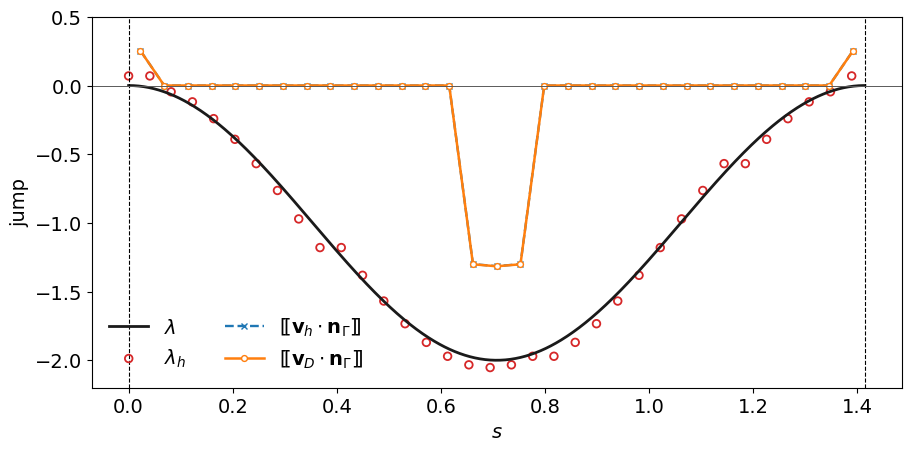

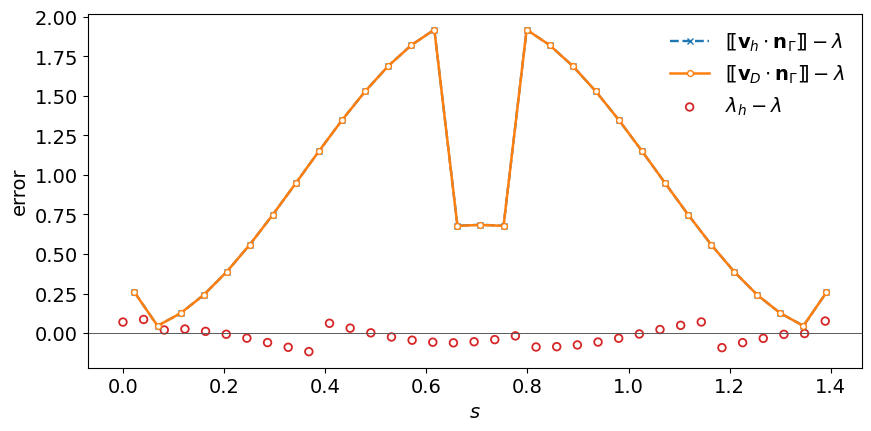

Real fracture jump vs lambda_exact (excluding 10% tips):
  CG    max=1.919e+00  mean=1.069e+00  L2=1.281e+00
  Deng  max=1.919e+00  mean=1.069e+00  L2=1.281e+00
  lam_h max=1.258e-01  mean=4.966e-02  L2=6.169e-02
No ghost extension: the physical fracture spans the full domain diagonal.


/tmp/ipykernel_3058433/2084562640.py:81: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  CG    max={np.max(np.abs(err_cg_jump)):.3e}  mean={np.mean(np.abs(err_cg_jump)):.3e}  L2={np.sqrt(np.trapz(err_cg_jump**2, s_mid_jump[mask_mid])):.3e}")
/tmp/ipykernel_3058433/2084562640.py:82: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  Deng  max={np.max(np.abs(err_deng_jump)):.3e}  mean={np.mean(np.abs(err_deng_jump)):.3e}  L2={np.sqrt(np.trapz(err_deng_jump**2, s_mid_jump[mask_mid])):.3e}")
/tmp/ipykernel_3058433/2084562640.py:83: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  lam_h max={np.max(np.abs(err_lh)):.3e}  mean={np.mean(np.abs(err_lh)):.3e}  L2={np.sqrt(np.trapz(err_lh**2, s_real[mask_r

In [59]:
def cg_jump_on_fracture(ctx, gdata, s_query, eps=None):
    if eps is None:
        eps = 0.1 * gdata["h_est"]
    s_query = np.asarray(s_query, dtype=float).reshape(-1)
    x0 = gdata["real_points_np"](s_query)
    normal = gdata["normal_np"]
    qp = q_cg_numpy(ctx, gdata, x0 + eps * normal[None, :])
    qm = q_cg_numpy(ctx, gdata, x0 - eps * normal[None, :])
    return np.sum((qp - qm) * normal[None, :], axis=1)


def deng_jump_on_fracture(ctx, local_fluxes, gdata, s_query, eps=None):
    if eps is None:
        eps = 0.1 * gdata["h_est"]
    s_query = np.asarray(s_query, dtype=float).reshape(-1)
    x0 = gdata["real_points_np"](s_query)
    normal = gdata["normal_np"]
    qp = q_rec_numpy(ctx, local_fluxes, gdata, x0 + eps * normal[None, :])
    qm = q_rec_numpy(ctx, local_fluxes, gdata, x0 - eps * normal[None, :])
    return np.sum((qp - qm) * normal[None, :], axis=1)


N_REAL = max(128, 4 * int(ctx_demo.get("n_gamma", 32)))
s_real = np.linspace(0.0, gdata_demo["L_gamma"], N_REAL)
x_real = gdata_demo["real_points_np"](s_real)
lambda_h_real = lambda_h_on_s(ctx_demo, gdata_demo, s_real)
lambda_exact_real = lambda_exact_xy(x_real[:, 0], x_real[:, 1])

# Use P0 multiplier interval midpoints for CG and Deng jump comparison.
s_nodes_jump = np.asarray(ctx_demo.get("lambda_s_nodes", []), dtype=float)
if len(s_nodes_jump) < 2:
    dof_points_jump = ctx_demo["V_l"].tabulate_dof_coordinates()[:, :2]
    s_nodes_jump = np.unique(np.round(np.sort(gdata_demo["s_coord_np"](dof_points_jump)), decimals=14))
s_mid_jump = 0.5 * (s_nodes_jump[:-1] + s_nodes_jump[1:])
x_mid_jump = gdata_demo["real_points_np"](s_mid_jump)
lambda_exact_mid = lambda_exact_xy(x_mid_jump[:, 0], x_mid_jump[:, 1])
jump_cg_mid = cg_jump_on_fracture(ctx_demo, gdata_demo, s_mid_jump)
jump_deng_mid = deng_jump_on_fracture(ctx_demo, lf_demo, gdata_demo, s_mid_jump)

fig, ax = plt.subplots(figsize=(9.0, 4.4), constrained_layout=True)
ax.plot(s_real, lambda_exact_real, color="0.10", lw=2.0, label=r"$\lambda$")
ax.scatter(s_real[::max(N_REAL // 34, 1)], lambda_h_real[::max(N_REAL // 34, 1)],
           s=30, facecolors="none", edgecolors="tab:red", linewidths=1.3, label=r"$\lambda_h$")
ax.plot(s_mid_jump, jump_cg_mid, "--", color="tab:blue", lw=1.7, marker="x", ms=4.5,
        markevery=max(len(s_mid_jump) // 34, 1), label=r"$[\![\mathbf{v}_h\cdot\mathbf{n}_\Gamma]\!]$")
ax.plot(s_mid_jump, jump_deng_mid, "-", color="tab:orange", lw=1.8, marker="o", ms=4.2,
        mfc="white", markevery=max(len(s_mid_jump) // 34, 1), label=r"$[\![\mathbf{v}_D\cdot\mathbf{n}_\Gamma]\!]$")
ax.axvline(0.0, color="k", ls="--", lw=0.8)
ax.axvline(gdata_demo["L_gamma"], color="k", ls="--", lw=0.8)
ax.axhline(0.0, color="0.35", lw=0.7)
ax.set_xlabel(r"$s$")
ax.set_ylabel(r"jump")
ax.set_ylim([-2.2,0.5])
ax.grid(False)
ax.legend(frameon=False, ncol=2, handlelength=2.0)
plt.show()

fig, ax = plt.subplots(figsize=(8.6, 4.2), constrained_layout=True)
ax.plot(s_mid_jump, jump_cg_mid - lambda_exact_mid, "--", color="tab:blue", lw=1.7,
        marker="x", ms=4.5, markevery=max(len(s_mid_jump) // 34, 1),
        label=r"$[\![\mathbf{v}_h\cdot\mathbf{n}_\Gamma]\!]-\lambda$")
ax.plot(s_mid_jump, jump_deng_mid - lambda_exact_mid, "-", color="tab:orange", lw=1.8,
        marker="o", ms=4.2, mfc="white", markevery=max(len(s_mid_jump) // 34, 1),
        label=r"$[\![\mathbf{v}_D\cdot\mathbf{n}_\Gamma]\!]-\lambda$")
ax.scatter(s_real[::max(N_REAL // 34, 1)], (lambda_h_real - lambda_exact_real)[::max(N_REAL // 34, 1)],
           s=30, facecolors="none", edgecolors="tab:red", linewidths=1.3,
           label=r"$\lambda_h-\lambda$")
ax.axhline(0.0, color="0.35", lw=0.7)
ax.set_xlabel(r"$s$")
ax.set_ylabel("error")
ax.grid(False)
ax.legend(frameon=False, handlelength=2.0)
plt.show()

mask_mid = (s_mid_jump >= TIP_FRAC * gdata_demo["L_gamma"]) & (s_mid_jump <= (1.0 - TIP_FRAC) * gdata_demo["L_gamma"])
mask_real = (s_real >= TIP_FRAC * gdata_demo["L_gamma"]) & (s_real <= (1.0 - TIP_FRAC) * gdata_demo["L_gamma"])
err_cg_jump = jump_cg_mid[mask_mid] - lambda_exact_mid[mask_mid]
err_deng_jump = jump_deng_mid[mask_mid] - lambda_exact_mid[mask_mid]
err_lh = lambda_h_real[mask_real] - lambda_exact_real[mask_real]
print(f"Real fracture jump vs lambda_exact (excluding {TIP_FRAC*100:.0f}% tips):")
print(f"  CG    max={np.max(np.abs(err_cg_jump)):.3e}  mean={np.mean(np.abs(err_cg_jump)):.3e}  L2={np.sqrt(np.trapz(err_cg_jump**2, s_mid_jump[mask_mid])):.3e}")
print(f"  Deng  max={np.max(np.abs(err_deng_jump)):.3e}  mean={np.mean(np.abs(err_deng_jump)):.3e}  L2={np.sqrt(np.trapz(err_deng_jump**2, s_mid_jump[mask_mid])):.3e}")
print(f"  lam_h max={np.max(np.abs(err_lh)):.3e}  mean={np.mean(np.abs(err_lh)):.3e}  L2={np.sqrt(np.trapz(err_lh**2, s_real[mask_real])):.3e}")

# Ghost-extension jump magnitude. For the full-diagonal MMS this block prints
# that no ghost extension is present.
x_ghost = gdata_demo["ghost_points_np"](n_each=max(64, N_REAL // 2))
if len(x_ghost):
    s_ghost = gdata_demo["s_coord_np"](x_ghost)
    jump_cg_ghost = cg_jump_on_fracture(ctx_demo, gdata_demo, s_ghost)
    jump_deng_ghost = deng_jump_on_fracture(ctx_demo, lf_demo, gdata_demo, s_ghost)
    fig, ax = plt.subplots(figsize=(8.6, 4.2), constrained_layout=True)
    ax.semilogy(s_ghost, np.abs(jump_cg_ghost) + 1e-30, "--", color="tab:blue", lw=1.7,
                label=r"$|[\![\mathbf{v}_h\cdot\mathbf{n}_\Gamma]\!]|$")
    ax.semilogy(s_ghost, np.abs(jump_deng_ghost) + 1e-30, "-", color="tab:orange", lw=1.8,
                label=r"$|[\![\mathbf{v}_D\cdot\mathbf{n}_\Gamma]\!]|$")
    ax.set_xlabel(r"$s$")
    ax.set_ylabel("magnitude")
    ax.grid(True, which="both", alpha=0.22)
    ax.legend(frameon=False, handlelength=2.0)
    plt.show()
else:
    print("No ghost extension: the physical fracture spans the full domain diagonal.")


## 3. Residual maps: element-wise and control-volume-wise

### Fracture-segment conservation residual

This evaluates the one-dimensional fracture balance on every fracture-pressure segment `e`:

`R_e = q_Gamma,e(s1-) - q_Gamma,e(s0+) + int_e lambda_h ds - int_e f_Gamma ds`.

The endpoint fluxes are evaluated from the local fracture-pressure element, so shared vertices are not averaged.


In [60]:
# Fracture-segment local conservation residual on Gamma.
# Endpoint fluxes are one-sided values from the current fracture-pressure segment e.

def _fracture_source_values_on_s(s_query):
    s_query = np.asarray(s_query, dtype=float).reshape(-1)
    pts = real_points_np(s_query)
    vals = np.asarray(f_gamma_exact_xy(pts[:, 0], pts[:, 1]), dtype=float)
    if vals.shape == ():
        vals = np.full(s_query.shape, float(vals), dtype=float)
    return vals.reshape(-1)


def _integrate_fracture_source_segment(s0, s1, nq=12):
    s0 = float(s0)
    s1 = float(s1)
    if s1 < s0:
        s0, s1 = s1, s0
    if s1 - s0 <= 1.0e-14:
        return 0.0
    xi, wi = np.polynomial.legendre.leggauss(int(nq))
    sq = 0.5 * (s0 + s1) + 0.5 * (s1 - s0) * xi
    return float(0.5 * (s1 - s0) * np.dot(wi, _fracture_source_values_on_s(sq)))


def _integrate_raw_lambda_segment(ctx, s0, s1, nq=12):
    s0 = float(s0)
    s1 = float(s1)
    if s1 < s0:
        s0, s1 = s1, s0
    if s1 - s0 <= 1.0e-14:
        return 0.0

    # The fracture block assembles +int lambda*psi, so use the RAW solved
    # multiplier. Do not apply lambda_balance_sign, which is only a matrix
    # diagnostic orientation flag.
    if "make_lambda_evaluator" in globals() and "integrate_lambda_s_interval" in globals():
        ctx_raw = dict(ctx)
        ctx_raw["lambda_balance_sign"] = 1.0
        return float(integrate_lambda_s_interval(s0, s1, make_lambda_evaluator(ctx_raw)))

    # Rectangular notebook path: integrate_lambda_interval evaluates the raw multiplier.
    if "integrate_lambda_interval" in globals():
        multiplier_data = _ctx_multiplier_data(ctx) if "_ctx_multiplier_data" in globals() else build_line_space_data(ctx["gamma_l"], ctx["V_l"])
        return float(integrate_lambda_interval(ctx, multiplier_data, s0, s1))

    # Fallback for future copies of this notebook.
    multiplier_data = build_line_space_data(ctx["gamma_l"], ctx["V_l"])
    lvals = np.asarray(ctx["lmbd"].x.array, dtype=float)
    xi, wi = np.polynomial.legendre.leggauss(int(nq))
    knots = [s0, s1]
    for cell in multiplier_data["cells"]:
        if s0 < cell["s0"] < s1:
            knots.append(float(cell["s0"]))
        if s0 < cell["s1"] < s1:
            knots.append(float(cell["s1"]))
    knots = np.asarray(sorted(set(np.round(knots, 14))), dtype=float)
    total = 0.0
    for a, b in zip(knots[:-1], knots[1:]):
        if b - a <= 1.0e-14:
            continue
        sq = 0.5 * (a + b) + 0.5 * (b - a) * xi
        vals = np.zeros_like(sq)
        for i, sv in enumerate(sq):
            line_cell = locate_line_cell_s(float(sv), multiplier_data)
            phi = line_values_derivatives_on_cell(line_cell, np.array([sv]))[0][0]
            vals[i] = float(phi @ lvals[line_cell["dofs"]])
        total += 0.5 * (b - a) * float(np.dot(wi, vals))
    return total


def _abs_stats(values):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return {"n": 0, "mean": np.nan, "max": np.nan}
    abs_values = np.abs(values)
    return {"n": int(values.size), "mean": float(np.mean(abs_values)), "max": float(np.max(abs_values))}


def compute_fracture_segment_residuals(ctx, tip_frac=None, nq_lambda=12, nq_source=12):
    pf_data = build_line_space_data(ctx["gamma"], ctx["V_f"])
    pvals = np.asarray(ctx["p_f"].x.array, dtype=float)
    if tip_frac is None:
        tip_frac = float(globals().get("TIP_FRAC", globals().get("CONV_TIP_FRAC", 0.0)))

    rows = []
    residuals = []
    s_mid = []
    for seg_id, cell in enumerate(pf_data["cells"]):
        s0 = float(cell["s0"])
        s1 = float(cell["s1"])

        # These derivatives use the local element basis on segment e, avoiding
        # the multi-valued shared-vertex flux.
        _, dpsi0 = line_values_derivatives_on_cell(cell, np.array([s0], dtype=float))
        _, dpsi1 = line_values_derivatives_on_cell(cell, np.array([s1], dtype=float))
        q_s0_plus = -K_F_VALUE * float(dpsi0[0] @ pvals[cell["dofs"]])
        q_s1_minus = -K_F_VALUE * float(dpsi1[0] @ pvals[cell["dofs"]])
        flux_boundary = q_s1_minus - q_s0_plus

        lambda_int = _integrate_raw_lambda_segment(ctx, s0, s1, nq=nq_lambda)
        source_int = _integrate_fracture_source_segment(s0, s1, nq=nq_source)
        R_e = flux_boundary + lambda_int - source_int

        residuals.append(R_e)
        mid = 0.5 * (s0 + s1)
        s_mid.append(mid)
        rows.append({
            "segment": int(seg_id),
            "cell": int(cell["cell_id"]),
            "s0": s0,
            "s1": s1,
            "s_mid": mid,
            "q_gamma_s0_plus": q_s0_plus,
            "q_gamma_s1_minus": q_s1_minus,
            "flux_boundary": flux_boundary,
            "lambda_int": lambda_int,
            "source_int": source_int,
            "R_e": R_e,
            "abs_R_e": abs(R_e),
        })

    residuals = np.asarray(residuals, dtype=float)
    s_mid = np.asarray(s_mid, dtype=float)
    L = float(ctx.get("L_gamma", globals().get("L_gamma", s_mid.max() if s_mid.size else 1.0)))
    interior = (s_mid >= tip_frac * L) & (s_mid <= (1.0 - tip_frac) * L)
    all_stats = _abs_stats(residuals)
    interior_stats = _abs_stats(residuals[interior])
    stats = {
        "n_segments": all_stats["n"],
        "mean_abs": all_stats["mean"],
        "max_abs": all_stats["max"],
        "tip_frac": float(tip_frac),
        "n_interior": interior_stats["n"],
        "mean_abs_interior": interior_stats["mean"],
        "max_abs_interior": interior_stats["max"],
    }
    return rows, residuals, stats


fracture_segment_rows, R_gamma_e, fracture_segment_stats = compute_fracture_segment_residuals(ctx_demo)
q0_vals = np.array([r["q_gamma_s0_plus"] for r in fracture_segment_rows], dtype=float)
q1_vals = np.array([r["q_gamma_s1_minus"] for r in fracture_segment_rows], dtype=float)
q_endpoint_vals = np.r_[q0_vals, q1_vals]
flux_boundary_vals = np.array([r["flux_boundary"] for r in fracture_segment_rows], dtype=float)
lambda_int_vals = np.array([r["lambda_int"] for r in fracture_segment_rows], dtype=float)
source_int_vals = np.array([r["source_int"] for r in fracture_segment_rows], dtype=float)
print("Fracture-segment residual R_e = q_Gamma,e(s1-) - q_Gamma,e(s0+) + int_e lambda_h ds - int_e f_Gamma ds")
print("  sign convention: net tangential flux out - int_e f_Gamma ds + int_e lambda_h ds")
print("  flux in R_e is raw CG fracture flux q_Gamma,h = -K_F d_s p_Gamma,h from the local element")
print("  flux values use the local fracture-pressure segment e")
print(f"  q_Gamma,h endpoint min/max = {q_endpoint_vals.min():.6e}, {q_endpoint_vals.max():.6e}")
print(f"  |q_Gamma,h| endpoint mean/max = {np.mean(np.abs(q_endpoint_vals)):.6e}, {np.max(np.abs(q_endpoint_vals)):.6e}")
print(f"  |q_Gamma,h(s1)-q_Gamma,h(s0)| mean/max = {np.mean(np.abs(flux_boundary_vals)):.6e}, {np.max(np.abs(flux_boundary_vals)):.6e}")
print(f"  |int_e f_Gamma ds| mean/max = {np.mean(np.abs(source_int_vals)):.6e}, {np.max(np.abs(source_int_vals)):.6e}")
print(f"  |int_e lambda_h ds| mean/max = {np.mean(np.abs(lambda_int_vals)):.6e}, {np.max(np.abs(lambda_int_vals)):.6e}")
print(f"  segments       = {fracture_segment_stats['n_segments']}")
print(f"  mean |R_e|     = {fracture_segment_stats['mean_abs']:.6e}")
print(f"  max  |R_e|     = {fracture_segment_stats['max_abs']:.6e}")
print(f"  interior count = {fracture_segment_stats['n_interior']}  (excluding {fracture_segment_stats['tip_frac']*100:.0f}% tips)")
print(f"  interior mean  = {fracture_segment_stats['mean_abs_interior']:.6e}")
print(f"  interior max   = {fracture_segment_stats['max_abs_interior']:.6e}")

try:
    import pandas as pd
    fracture_segment_residual_table = pd.DataFrame(fracture_segment_rows)
    display(fracture_segment_residual_table)
except Exception:
    fracture_segment_residual_table = fracture_segment_rows
    print(fracture_segment_rows[:5])


Fracture-segment residual R_e = q_Gamma,e(s1-) - q_Gamma,e(s0+) + int_e lambda_h ds - int_e f_Gamma ds
  sign convention: net tangential flux out - int_e f_Gamma ds + int_e lambda_h ds
  flux in R_e is raw CG fracture flux q_Gamma,h = -K_F d_s p_Gamma,h from the local element
  flux values use the local fracture-pressure segment e
  q_Gamma,h endpoint min/max = -2.221479e+02, 2.221479e+02
  |q_Gamma,h| endpoint mean/max = 1.414337e+02, 2.221479e+02
  |q_Gamma,h(s1)-q_Gamma,h(s0)| mean/max = 0.000000e+00, 0.000000e+00
  |int_e f_Gamma ds| mean/max = 4.876701e+00, 7.667560e+00
  |int_e lambda_h ds| mean/max = 7.987997e-03, 1.595376e-02
  segments       = 182
  mean |R_e|     = 4.881741e+00
  max  |R_e|     = 7.668102e+00
  interior count = 146  (excluding 10% tips)
  interior mean  = 4.313775e+00
  interior max   = 7.667973e+00


,segment,cell,s0,s1,s_mid,q_gamma_s0_plus,q_gamma_s1_minus,flux_boundary,lambda_int,source_int,R_e,abs_R_e
0,0,0,0.000000,0.007770,0.003885,-3.847961,-3.847961,0.0,0.000542,-7.667560,7.668102,7.668102
1,1,1,0.007770,0.015541,0.011656,-11.512259,-11.512259,0.0,0.000542,-7.658431,7.658973,7.658973
2,2,2,0.015541,0.023311,0.019426,-19.162869,-19.162869,0.0,0.000542,-7.640186,7.640728,7.640728
3,3,3,0.023311,0.031082,0.027196,-26.790682,-26.790682,0.0,0.000542,-7.612844,7.613386,7.613386
4,4,4,0.031082,0.038852,0.034967,-34.386620,-34.386620,0.0,0.000542,-7.576440,7.576982,7.576982
...,...,...,...,...,...,...,...,...,...,...,...,...
177,177,177,1.375362,1.383132,1.379247,34.386620,34.386620,0.0,0.000542,-7.576440,7.576982,7.576982
178,178,178,1.383132,1.390902,1.387017,26.790682,26.790682,0.0,0.000542,-7.612844,7.613386,7.613386
179,179,179,1.390902,1.398673,1.394788,19.162869,19.162869,0.0,0.000542,-7.640186,7.640728,7.640728
180,180,180,1.398673,1.406443,1.402558,11.512259,11.512259,0.0,0.000542,-7.658431,7.658973,7.658973


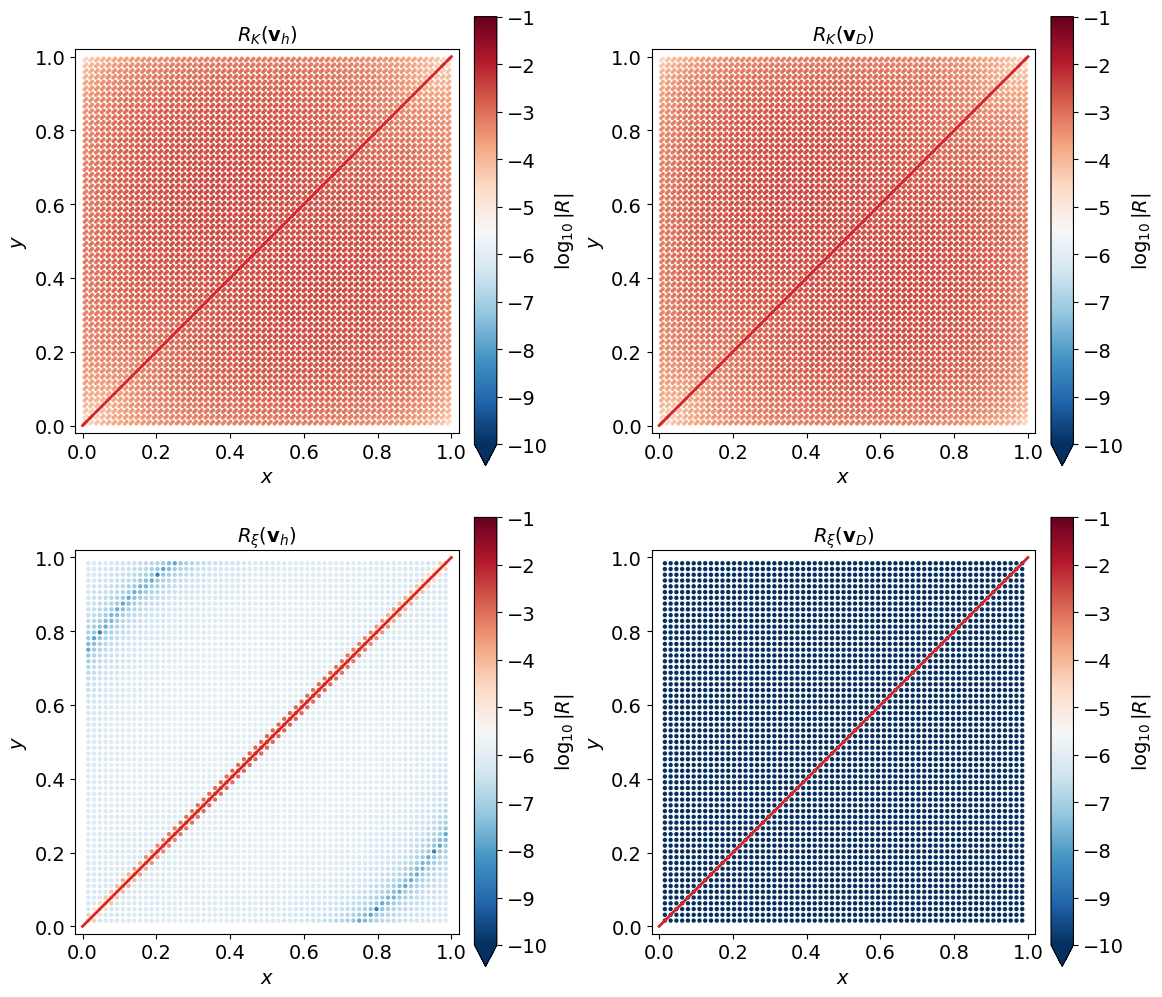

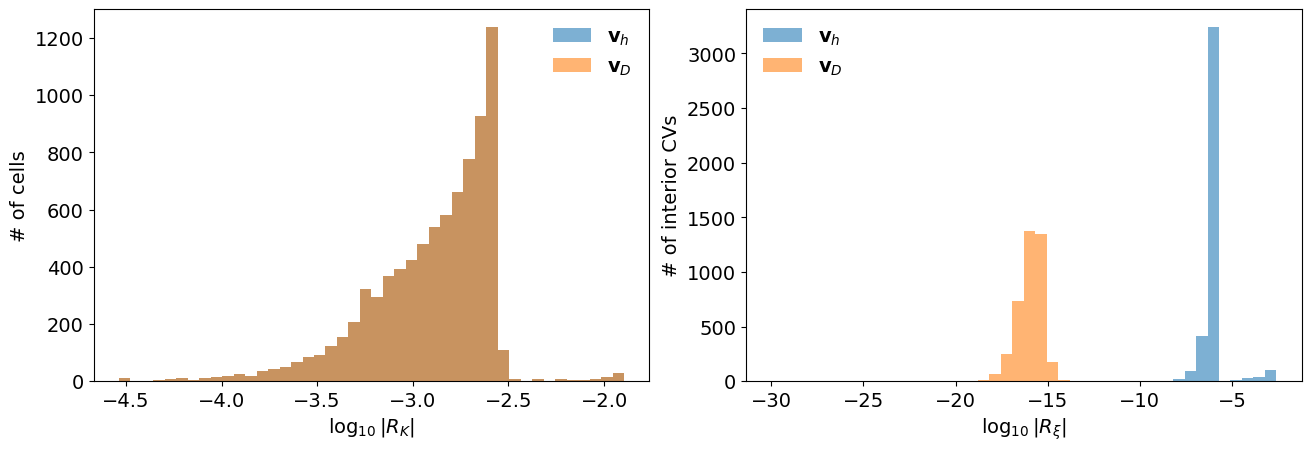

In [61]:
def _log_res(values, eps=1e-30):
    return np.log10(np.abs(values) + eps)


def _map_extend(log_values):
    lo = np.nanmin(log_values)
    hi = np.nanmax(log_values)
    if lo < RK_LOG_VMIN and hi > RK_LOG_VMAX:
        return "both"
    if lo < RK_LOG_VMIN:
        return "min"
    if hi > RK_LOG_VMAX:
        return "max"
    return "neither"


cent = gdata_demo["cell_centroids"]
cv_xy = cv_coords_demo
cv_plot_ids = interior_cv_ids
map_specs = [
    ("Element", r"$R_K(\mathbf{v}_h)$", cent, R_elem_cg),
    ("Element", r"$R_K(\mathbf{v}_D)$", cent, R_elem_rec),
    ("CV", r"$R_\xi(\mathbf{v}_h)$", cv_xy[cv_plot_ids], R_cv_cg[cv_plot_ids]),
    ("CV", r"$R_\xi(\mathbf{v}_D)$", cv_xy[cv_plot_ids], R_cv_rec[cv_plot_ids]),
]
all_logs = np.concatenate([_log_res(vals) for _, _, _, vals in map_specs])
extend = _map_extend(all_logs)

fig, axes = plt.subplots(2, 2, figsize=(11.5, 10.0), constrained_layout=True)
for ax, (kind, title, xy, vals) in zip(axes.ravel(), map_specs):
    sc = ax.scatter(
        xy[:, 0], xy[:, 1], c=_log_res(vals), s=8 if kind == "Element" else 10,
        cmap="RdBu_r", vmin=RK_LOG_VMIN, vmax=RK_LOG_VMAX,
        linewidths=0.0, rasterized=True,
    )
    plot_fracture_lines(ax, gdata_demo)
    ax.set_aspect("equal")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(title)
    ax.grid(False)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    cbar = fig.colorbar(sc, ax=ax, label=r"$\log_{10}|R|$", extend=extend, pad=0.02)
    cbar.set_ticks(RK_CBAR_TICKS)
plt.show()

# Distribution over all matrix cells and all interior CVs.
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4), constrained_layout=True)
lo_e = min(_log_res(R_elem_cg).min(), _log_res(R_elem_rec).min())
hi_e = max(_log_res(R_elem_cg).max(), _log_res(R_elem_rec).max())
bins_e = np.linspace(lo_e, hi_e, 45)
axes[0].hist(_log_res(R_elem_cg), bins=bins_e, alpha=0.58, label=r"$\mathbf{v}_h$", color="tab:blue")
axes[0].hist(_log_res(R_elem_rec), bins=bins_e, alpha=0.58, label=r"$\mathbf{v}_D$", color="tab:orange")
axes[0].set_xlabel(r"$\log_{10}|R_K|$")
axes[0].set_ylabel("# of cells")
axes[0].grid(False)
axes[0].legend(frameon=False)

lo_cv = min(_log_res(R_cv_cg[interior_cv_ids]).min(), _log_res(R_cv_rec[interior_cv_ids]).min())
hi_cv = max(_log_res(R_cv_cg[interior_cv_ids]).max(), _log_res(R_cv_rec[interior_cv_ids]).max())
bins_cv = np.linspace(lo_cv, hi_cv, 45)
axes[1].hist(_log_res(R_cv_cg[interior_cv_ids]), bins=bins_cv, alpha=0.58, label=r"$\mathbf{v}_h$", color="tab:blue")
axes[1].hist(_log_res(R_cv_rec[interior_cv_ids]), bins=bins_cv, alpha=0.58, label=r"$\mathbf{v}_D$", color="tab:orange")
axes[1].set_xlabel(r"$\log_{10}|R_\xi|$")
axes[1].set_ylabel("# of interior CVs")
axes[1].grid(False)
axes[1].legend(frameon=False)
plt.show()


## 4. Quantitative comparison table

In [62]:
def print_stats_block(label, before, after, ids_all, ids_focus, focus_label):
    b_all = residual_stats(before, ids_all)
    a_all = residual_stats(after, ids_all)
    b_focus = residual_stats(before, ids_focus)
    a_focus = residual_stats(after, ids_focus)
    imp = improvement_stats(before, after, ids_focus)

    print(label)
    print(f"  all/interior count     = {b_all['n']}")
    print(f"  focus count ({focus_label}) = {b_focus['n']}")
    print(f"  CG    mean={b_all['mean']:.3e} median={b_all['median']:.3e} max={b_all['max']:.3e} | focus mean={b_focus['mean']:.3e} max={b_focus['max']:.3e}")
    print(f"  Deng  mean={a_all['mean']:.3e} median={a_all['median']:.3e} max={a_all['max']:.3e} | focus mean={a_focus['mean']:.3e} max={a_focus['max']:.3e}")
    print(f"  focus improved={imp[0]:.1f}% ratio mean={imp[1]:.3e} median={imp[2]:.3e} max={imp[3]:.3e}")
    print()
    return b_all, a_all, b_focus, a_focus, imp


all_cell_ids = np.arange(gdata_demo["num_cells"], dtype=np.int32)
print("Quantitative local-conservation comparison")
print(f"ref={REF_DEMO}, h={ctx_demo['h']:.4e}, total computation time={total_computation_time:.4f} s")
print()
elem_stats = print_stats_block(
    "Element-wise residual R_K",
    R_elem_cg, R_elem_rec, all_cell_ids, frac_cell_ids, "fracture-cut cells"
)
cv_stats = print_stats_block(
    "Control-volume residual R_xi",
    R_cv_cg, R_cv_rec, interior_cv_ids, fracture_cv_ids, "interior fracture-cut CVs"
)


Quantitative local-conservation comparison
ref=6, h=1.5625e-02, total computation time=79.8819 s

Element-wise residual R_K
  all/interior count     = 8192
  focus count (fracture-cut cells) = 128
  CG    mean=1.575e-03 median=1.492e-03 max=1.270e-02 | focus mean=6.356e-03 max=1.270e-02
  Deng  mean=1.575e-03 median=1.492e-03 max=1.270e-02 | focus mean=6.356e-03 max=1.270e-02
  focus improved=21.9% ratio mean=1.000e+00 median=1.000e+00 max=1.000e+00

Control-volume residual R_xi
  all/interior count     = 3969
  focus count (interior fracture-cut CVs) = 187
  CG    mean=4.143e-05 median=8.682e-07 max=2.535e-03 | focus mean=8.633e-04 max=2.535e-03
  Deng  mean=2.638e-16 median=1.440e-16 max=1.772e-14 | focus mean=6.883e-16 max=1.772e-14
  focus improved=100.0% ratio mean=8.313e-13 median=3.991e-13 max=2.174e-11



## 5. Local conservation around the fracture

Fracture-cut cells      : 128
Interior fracture-cut CV dofs: 187


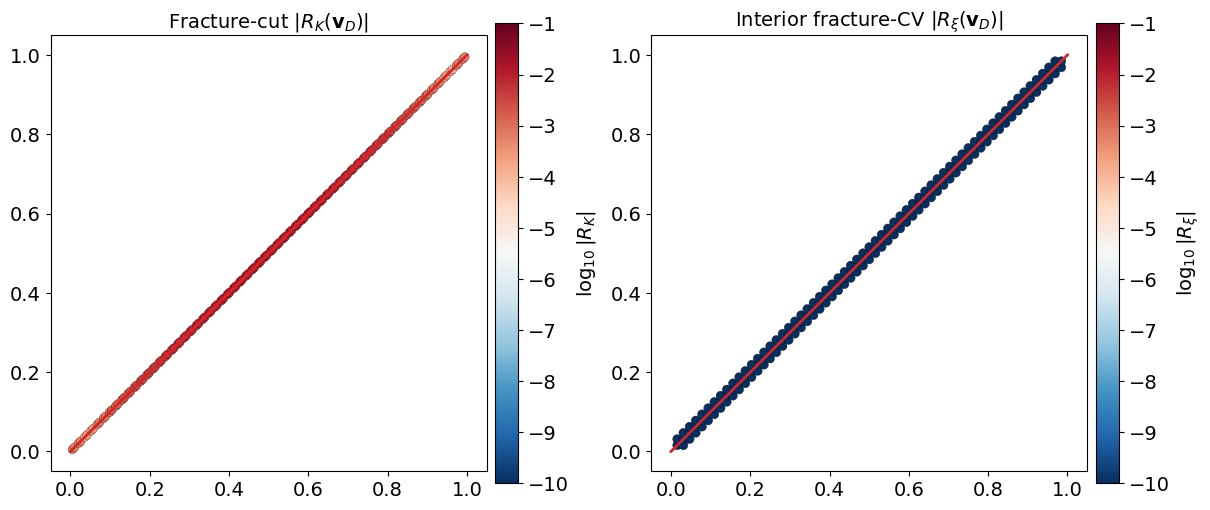

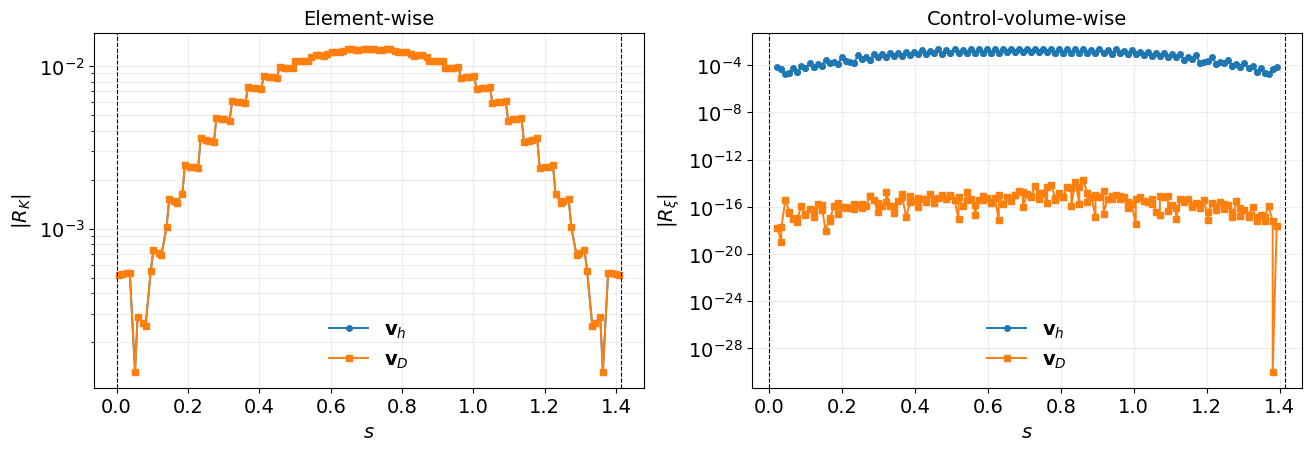


Fracture-cut element residuals (n=128):
  CG    mean=6.356e-03 median=6.056e-03 max=1.270e-02
  Deng  mean=6.356e-03 median=6.056e-03 max=1.270e-02
  improved=21.9% ratio mean=1.000e+00 median=1.000e+00 max=1.000e+00

Interior fracture-cut CV residuals (n=187):
  CG    mean=8.633e-04 median=8.452e-04 max=2.535e-03
  Deng  mean=6.883e-16 median=2.168e-16 max=1.772e-14
  improved=100.0% ratio mean=8.313e-13 median=3.991e-13 max=2.174e-11


In [63]:
cent_frac = gdata_demo["cell_centroids"][frac_cell_ids]
s_elem_frac = gdata_demo["s_coord_np"](cent_frac) if len(frac_cell_ids) else np.array([])
cv_frac_xy = cv_coords_demo[fracture_cv_ids]
s_cv_frac = gdata_demo["s_coord_np"](cv_frac_xy) if len(fracture_cv_ids) else np.array([])

print(f"Fracture-cut cells      : {len(frac_cell_ids)}")
print(f"Interior fracture-cut CV dofs: {len(fracture_cv_ids)}")

fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.0), constrained_layout=True)
if len(frac_cell_ids):
    sc0 = axes[0].scatter(
        cent_frac[:, 0], cent_frac[:, 1], c=_log_res(R_elem_rec[frac_cell_ids]),
        s=40, cmap="RdBu_r", vmin=RK_LOG_VMIN, vmax=RK_LOG_VMAX,
        edgecolors="k", linewidths=0.2, rasterized=True,
    )
    plot_fracture_lines(axes[0], gdata_demo)
    axes[0].set_title(r"Fracture-cut $|R_K(\mathbf{v}_D)|$")
    axes[0].set_aspect("equal")
    axes[0].grid(False)
    fig.colorbar(sc0, ax=axes[0], label=r"$\log_{10}|R_K|$", pad=0.02)
else:
    axes[0].set_title("No fracture-cut cells")

if len(fracture_cv_ids):
    sc1 = axes[1].scatter(
        cv_frac_xy[:, 0], cv_frac_xy[:, 1], c=_log_res(R_cv_rec[fracture_cv_ids]),
        s=42, cmap="RdBu_r", vmin=RK_LOG_VMIN, vmax=RK_LOG_VMAX,
        edgecolors="k", linewidths=0.2, rasterized=True,
    )
    plot_fracture_lines(axes[1], gdata_demo)
    axes[1].set_title(r"Interior fracture-CV $|R_\xi(\mathbf{v}_D)|$")
    axes[1].set_aspect("equal")
    axes[1].grid(False)
    fig.colorbar(sc1, ax=axes[1], label=r"$\log_{10}|R_\xi|$", pad=0.02)
else:
    axes[1].set_title("No interior fracture CVs")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4), constrained_layout=True)
if len(frac_cell_ids):
    idx = np.argsort(s_elem_frac)
    axes[0].semilogy(s_elem_frac[idx], np.abs(R_elem_cg[frac_cell_ids][idx]) + 1e-30,
                     "o-", ms=4, lw=1.4, label=r"$\mathbf{v}_h$")
    axes[0].semilogy(s_elem_frac[idx], np.abs(R_elem_rec[frac_cell_ids][idx]) + 1e-30,
                     "s-", ms=4, lw=1.4, label=r"$\mathbf{v}_D$")
    axes[0].axvline(0.0, color="k", ls="--", lw=0.8)
    axes[0].axvline(gdata_demo["L_gamma"], color="k", ls="--", lw=0.8)
    axes[0].set_xlabel(r"$s$")
    axes[0].set_ylabel(r"$|R_K|$")
    axes[0].set_title("Element-wise")
    axes[0].grid(True, which="both", alpha=0.22)
    axes[0].legend(frameon=False)

if len(fracture_cv_ids):
    idx = np.argsort(s_cv_frac)
    axes[1].semilogy(s_cv_frac[idx], np.abs(R_cv_cg[fracture_cv_ids][idx]) + 1e-30,
                     "o-", ms=4, lw=1.4, label=r"$\mathbf{v}_h$")
    axes[1].semilogy(s_cv_frac[idx], np.abs(R_cv_rec[fracture_cv_ids][idx]) + 1e-30,
                     "s-", ms=4, lw=1.4, label=r"$\mathbf{v}_D$")
    axes[1].axvline(0.0, color="k", ls="--", lw=0.8)
    axes[1].axvline(gdata_demo["L_gamma"], color="k", ls="--", lw=0.8)
    axes[1].set_xlabel(r"$s$")
    axes[1].set_ylabel(r"$|R_\xi|$")
    axes[1].set_title("Control-volume-wise")
    axes[1].grid(True, which="both", alpha=0.22)
    axes[1].legend(frameon=False)
plt.show()

for label, before, after, ids in [
    ("Fracture-cut element residuals", R_elem_cg, R_elem_rec, frac_cell_ids),
    ("Interior fracture-cut CV residuals", R_cv_cg, R_cv_rec, fracture_cv_ids),
]:
    b = residual_stats(before, ids)
    a = residual_stats(after, ids)
    imp = improvement_stats(before, after, ids)
    print(f"\n{label} (n={b['n']}):")
    print(f"  CG    mean={b['mean']:.3e} median={b['median']:.3e} max={b['max']:.3e}")
    print(f"  Deng  mean={a['mean']:.3e} median={a['median']:.3e} max={a['max']:.3e}")
    print(f"  improved={imp[0]:.1f}% ratio mean={imp[1]:.3e} median={imp[2]:.3e} max={imp[3]:.3e}")


In [64]:
ctx_demo["lambda_balance_sign"]

1.0